**Interaktive Exploration der Proximity-Funktion**
In der unterliegenen Zelle können die Parameter der Proximity-Funktion (z. B. Schärfe, Frequenzabfall, maximal zu berücksichtigende Frequenz) über ein interaktives Widget dynamisch verändert und die resultierende Kurve visualisiert werden. Dies erlaubt eine intuitive Erkundung der Funktion und ihrer Auswirkungen auf die Bewertung der rhythmischen Verhältnisse.

In [ ]:
# Proximity Funktion mit flexibler Anpassung
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider
import numpy as np
from scipy.integrate import simpson
from scipy.stats import gaussian_kde

# Proximity-Funktion: bewertet Zahlenverhältnisse nach harmonischen Kriterien
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    all_freq_values = []

    for freq in range(1, max_freq + 1):
        weight = 1 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)
        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        # Normierung auf norm_x
        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        cos_term_normalized = cos_term / peak_value

        val = weight * cos_term_normalized / (x ** decay)
        all_freq_values.append(val)

    result = np.maximum.reduce(all_freq_values)

    max_at_norm_x = np.max([
        (1 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in range(1, max_freq + 1)
    ])
    return result / max_at_norm_x * output_max

# Plot-Funktion für Proximity und dessen Verteilung
def plot_proximity_max_freq(
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.5,
    max_freq=6,
    weight_exponent=1.0,
    freq_sharpness_exp=0.5
):
    x_vals = np.linspace(1, 5, 1000)
    y_vals = proximity_max_freq(
        x_vals,
        sharpness_base=sharpness_base,
        sharpness_growth=sharpness_growth,
        decay=decay,
        max_freq=max_freq,
        weight_exponent=weight_exponent,
        freq_sharpness_exp=freq_sharpness_exp,
        output_max=1.0,
    )

    # Integral = numerischer Mittelwert der Funktion
    mean_prox = simpson(y_vals, x=x_vals) / (x_vals[-1] - x_vals[0])

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle("Einfluss von Parametern auf Proximity-Funktion", fontsize=16, y=1.02)

    # Plot der Proximity-Funktion
    axes[0].plot(x_vals, y_vals, label=f"Proximity (∫mean ≈ {mean_prox:.3f})")
    axes[0].plot(
        x_vals,
        [mean_prox] * len(x_vals),
        color='red',
        linestyle='--',
        linewidth=2,
        label=f"∫mean ≈ {mean_prox:.3f}"
    )
    axes[0].set_xlabel("x (Verhältnis)")
    axes[0].set_ylabel("Proximity")
    axes[0].set_title("Proximity mit frequenzabhängiger Sharpness")
    axes[0].set_ylim(0, 1.05)
    axes[0].grid(True, linestyle="--", alpha=0.3)
    axes[0].legend()

    # Histogramm + KDE (Verteilung von y_vals)
    counts, bins_hist, _ = axes[1].hist(
        y_vals,
        bins=50,
        range=(0, 1),
        alpha=0.4,
        color="skyblue",
        density=True,
        label="Histogramm"
    )

    kde = gaussian_kde(y_vals)
    x_dens = np.linspace(0, 1, 5000)
    kde_vals = kde(x_dens)

    # Automatische Skalierung
    scaling_factor = max(counts) / max(kde_vals)
    axes[1].plot(
        x_dens,
        kde_vals * scaling_factor,
        color="darkblue",
        lw=2,
        label="Dichte (KDE)"
    )

    axes[1].axvline(
        mean_prox,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f"∫mean ≈ {mean_prox:.3f}"
    )
    axes[1].set_title("Proximity-Verteilung")
    axes[1].set_xlabel("Proximity")
    axes[1].set_ylabel("Normierte Häufigkeit")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()

# Interaktive Visualisierung
interact(
    plot_proximity_max_freq,
    sharpness_base=FloatSlider(min=1, max=50, step=1, value=10, description="Sharpness Base"),
    sharpness_growth=FloatSlider(min=0, max=3, step=0.1, value=2, description="Sharpness Growth"),
    decay=FloatSlider(min=0, max=3, step=0.05, value=0.1, description="Decay"),
    max_freq=IntSlider(min=1, max=12, step=1, value=4, description="Max Frequency"),
    weight_exponent=FloatSlider(min=0, max=3, step=0.1, value=1, description="Weight Exponent"),
    freq_sharpness_exp=FloatSlider(min=0, max=3, step=0.1, value=1, description="Freq Sharpness Exp"),
)


interactive(children=(FloatSlider(value=10.0, description='Sharpness Base', max=50.0, min=1.0, step=1.0), Floa…

<function __main__.plot_proximity_max_freq(sharpness_base=10.0, sharpness_growth=2.0, decay=0.5, max_freq=6, weight_exponent=1.0, freq_sharpness_exp=0.5)>

**Vergleich unterschiedlicher rhythmischer Sequenzen:**
Für eine Reihe synthetisch generierter Sequenzen aus dem Dataset *synthetic_sequences_20beats* wurden alle IOI-Verhältnisse berechnet, die Proximity-Werte ermittelt und die oberen Dreiecksmatrizen (ohne Diagonale) extrahiert. Diese wurden anschließend gruppiert nach Sequenztyp (z. B. "accelerando", "heterochron", "tempo_shift") und in einem Boxplot visualisiert.

Dies ermöglicht eine quantitative, vergleichende Analyse der Periodizitätsstruktur verschiedener rhythmischer Kategorien.

=== Rhythmic Complexity ===
Längste IOI (metric beat): 0.500 s
Rhythmic Complexity: 21

=== Verhältnis-Häufigkeiten (über threshold) ===
Keine Proximity: 19 mal
1/1: 171 mal


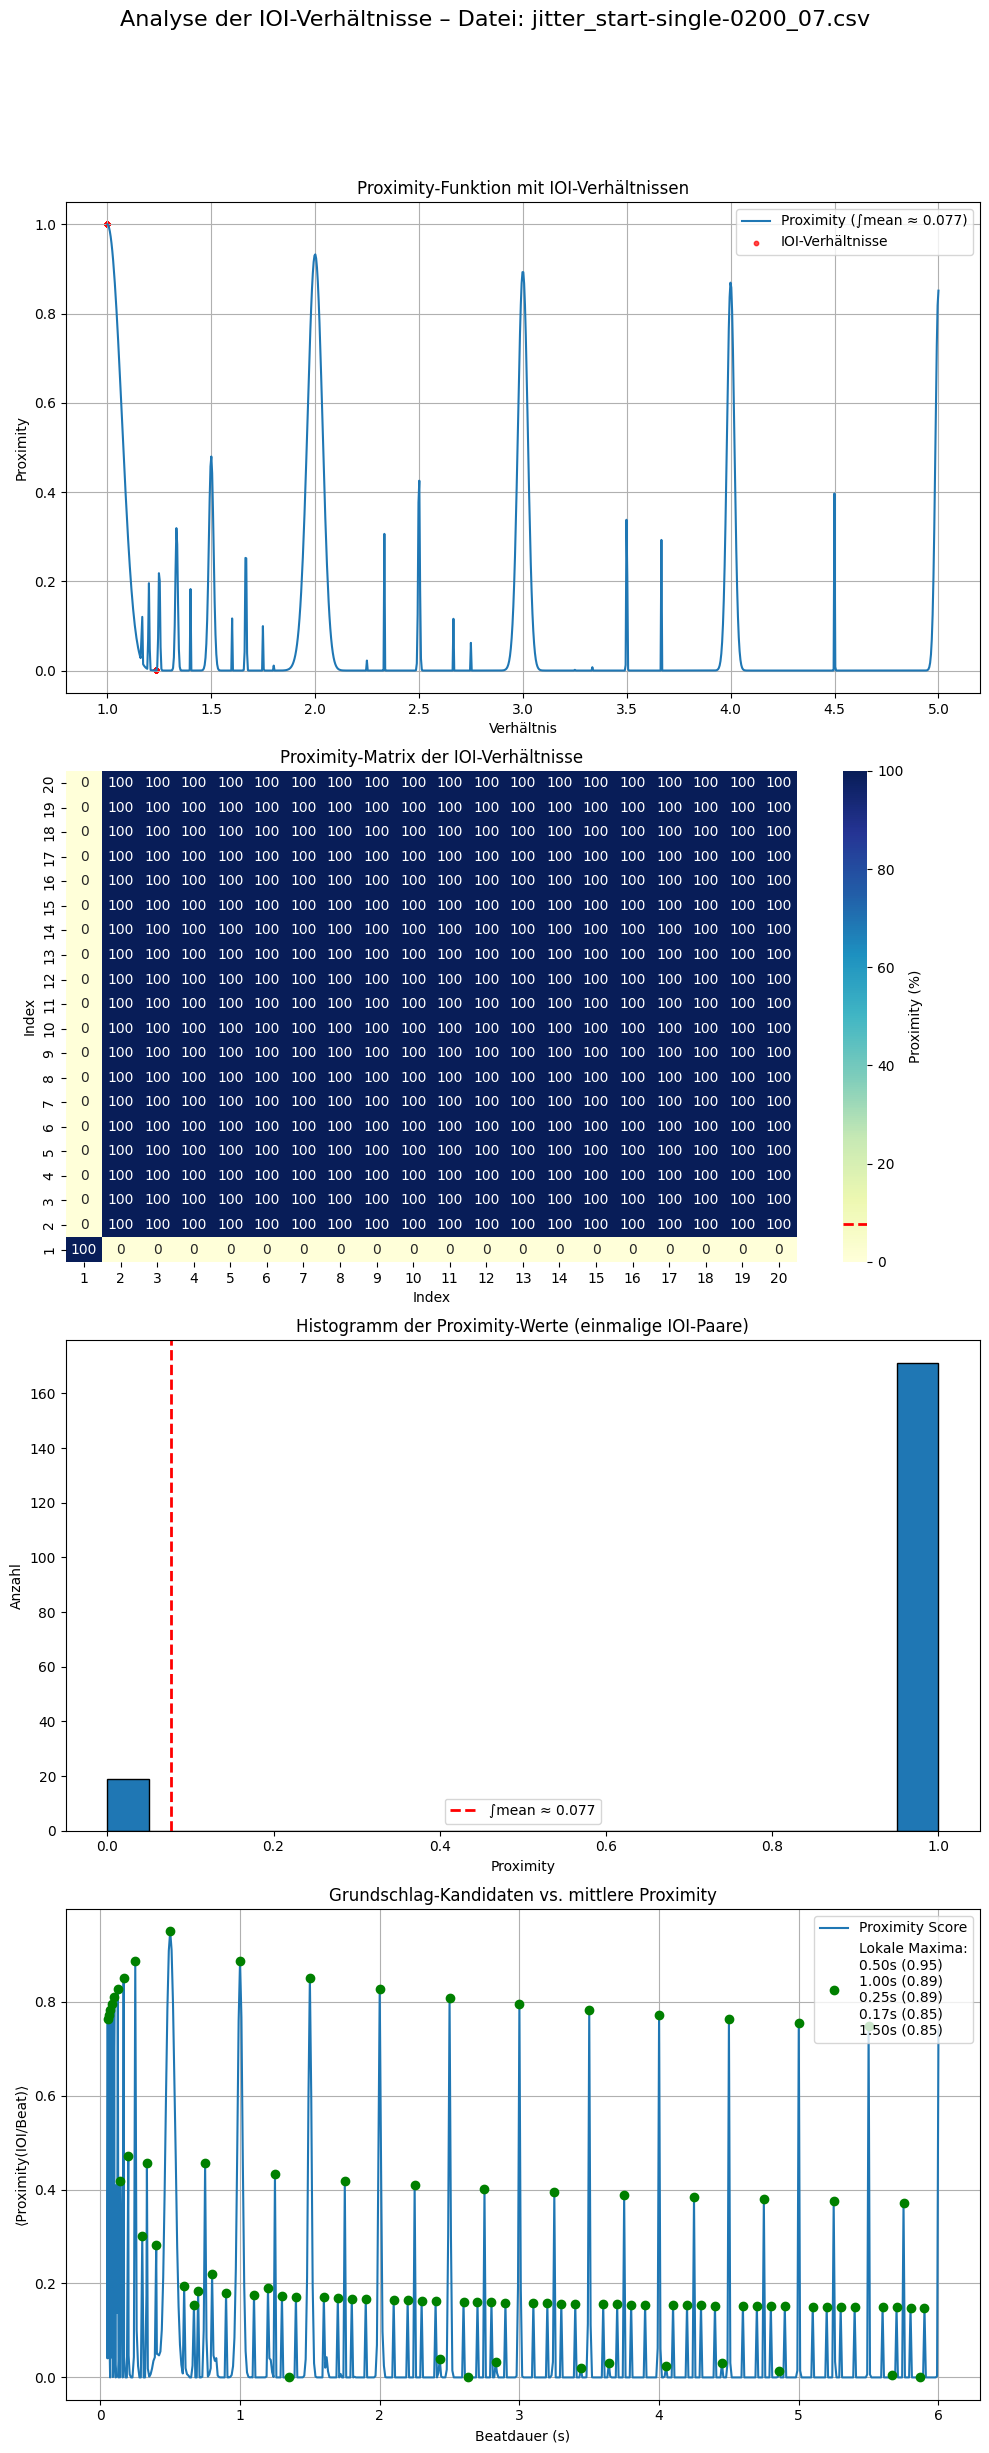

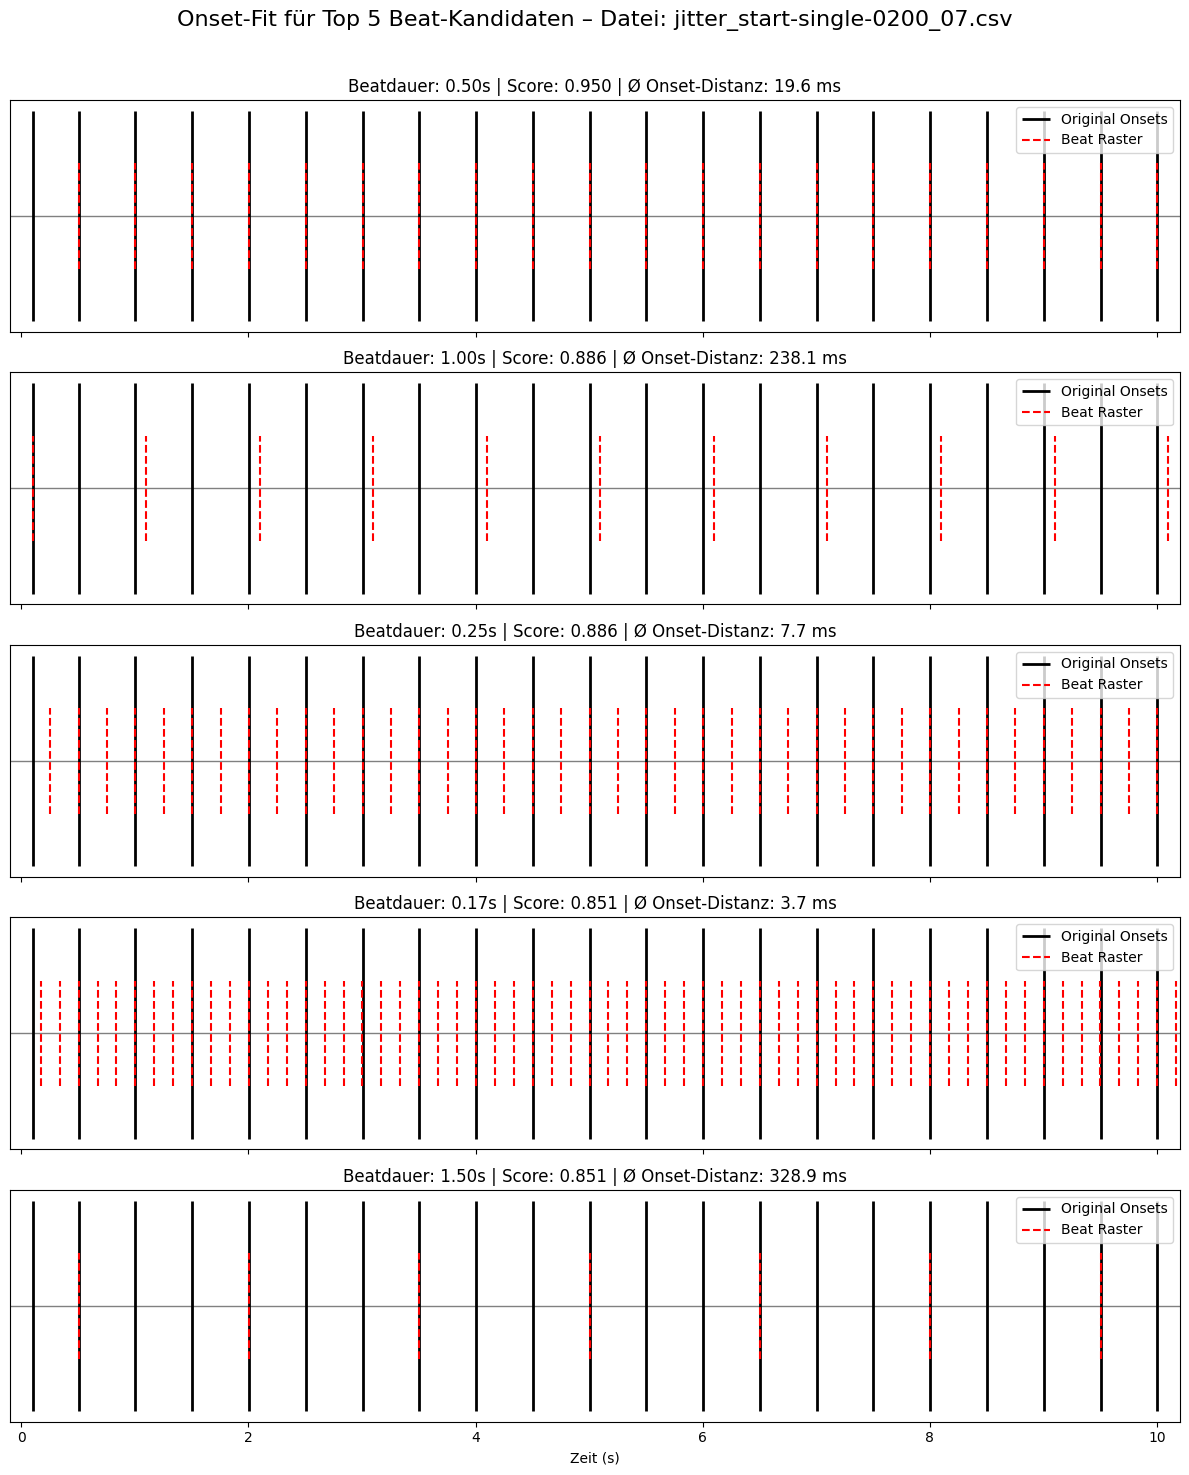


=== Pairwise-DataFrame (Kopf) ===
   i  j     ioi_i  ioi_j     ratio  proximity       peak_label
0  0  1  0.404708    0.5  1.235458   0.000167  Keine Proximity
1  0  2  0.404708    0.5  1.235458   0.000167  Keine Proximity
2  0  3  0.404708    0.5  1.235458   0.000167  Keine Proximity
3  0  4  0.404708    0.5  1.235458   0.000167  Keine Proximity
4  0  5  0.404708    0.5  1.235458   0.000167  Keine Proximity


In [ ]:
# (old!!!) === Analyse von IOI-Verhältnissen zur Beat-Detektion ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.integrate import simpson
from scipy.signal import argrelextrema
from fractions import Fraction
from collections import Counter

# =============================
# 1) Proximity-Funktion
# =============================
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    """
    Gibt zurück:
      proximity_max : ndarray wie x (maximale Proximity über alle f)
      peak_indices  : ndarray wie x (Index in 'freqs' des besten f)
      freqs         : ndarray der getesteten f (1..max_freq)
    """
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)  # shape: (num_freqs, *x.shape)
    peak_indices = np.argmax(all_freq_values, axis=0)
    proximity_max = np.max(all_freq_values, axis=0)

    # Normalisierung auf output_max
    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max, peak_indices, freqs

# =============================
# 2) Hilfsfunktionen
# =============================
def generate_beat_candidates_from_iois(iois, min_ioi=0.05, max_ioi=6.0, resolution=0.01, max_denominator=48):
    raster = np.arange(min_ioi, max_ioi + 1e-12, resolution)
    candidates = set(np.round(raster, 6))
    for ioi in iois:
        if ioi < min_ioi or ioi > max_ioi:
            continue
        for denom in range(1, max_denominator + 1):
            beat = ioi / denom
            if min_ioi <= beat <= max_ioi:
                candidates.add(float(Fraction(beat).limit_denominator(1000)))
    for denom in range(1, max_denominator + 1):
        val = 1.0 / denom
        if min_ioi <= val <= max_ioi:
            candidates.add(float(Fraction(val).limit_denominator(1000)))
    return sorted(candidates)

def score_for_beat(beat, iois, params):
    ratios = np.maximum(iois, beat) / np.minimum(iois, beat)
    prox_vals, _, _ = proximity_max_freq(ratios, **params)
    return float(np.mean(prox_vals))

def find_local_maxima(candidates, scores, order=2):
    indices = argrelextrema(np.array(scores), np.greater, order=order)[0]
    return [(candidates[i], scores[i]) for i in indices]

def build_pairwise_proximity_df(iois, params, threshold=0.01):
    """
    Baut einen DataFrame über alle IOI-Paare (nur obere Dreieck):
    Spalten: i, j, ioi_i, ioi_j, ratio (>=1), proximity, peak_label (oder 'Keine Proximity')
    Die peak_label orientiert sich am tatsächlich maximalen f:
      best_f = freqs[peak_idx], dann p = round(ratio*best_f) -> Label = (p/best_f) (gekürzt)
    """
    n = len(iois)
    # Ratio-Matrix (>=1)
    ratios = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j]) for j in range(n)] for i in range(n)])
    prox_max, peak_idx, freqs = proximity_max_freq(ratios, **params)

    rows = []
    for i in range(n):
        for j in range(i + 1, n):
            r = float(ratios[i, j])
            s = float(prox_max[i, j])
            if s > threshold:
                best_f = int(freqs[peak_idx[i, j]])      # 1..max_freq
                p = int(round(r * best_f))               # nächstgelegener Zähler
                frac = Fraction(p, best_f)               # automatisch gekürzt
                label = f"{frac.numerator}/{frac.denominator}"
            else:
                label = "Keine Proximity"

            rows.append({
                "i": i,
                "j": j,
                "ioi_i": float(iois[i]),
                "ioi_j": float(iois[j]),
                "ratio": r,
                "proximity": s,
                "peak_label": label
            })

    df_pairs = pd.DataFrame(rows)
    return df_pairs, ratios, prox_max

# =============================
# 3) Setup: Datei laden
# =============================
filename = "jitter_start-single-0200_07.csv"
base_dir = Path("../data/theoretical_sequences/baseIOI-0.50/20beats")
seq_path = base_dir / filename
if not seq_path.exists():
    raise FileNotFoundError(f"Datei nicht gefunden: {seq_path.resolve()}")

df = pd.read_csv(seq_path)
iois = df["IOI"].dropna().values
onsets = df["onset"].dropna().values

# =============================
# 4) Rhythmic Complexity
# =============================
longest_ioi = np.max(iois)
iois_normalized = [Fraction(ioi / longest_ioi).limit_denominator(48) for ioi in iois]
denominators = [frac.denominator for frac in iois_normalized]
complexity = np.lcm.reduce(denominators)

print("=== Rhythmic Complexity ===")
print(f"Längste IOI (metric beat): {longest_ioi:.3f} s")
print(f"Rhythmic Complexity: {complexity}")

# =============================
# 5) Parameter & Pairwise-DF
# =============================
params = dict(
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=6,              # bestimmt auch max. Nenner der Peak-Labels
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
)
PAIR_THRESHOLD = 0.01        # nur > threshold wird gezählt / gelabelt

df_pairs, ratios_mat, proximity_mat = build_pairwise_proximity_df(iois, params, threshold=PAIR_THRESHOLD)

# Häufigkeiten aus dem DF
counts = Counter(df_pairs["peak_label"])
# Sicherstellen, dass "Keine Proximity" auftaucht, auch wenn 0
counts.setdefault("Keine Proximity", 0)

print("\n=== Verhältnis-Häufigkeiten (über threshold) ===")
for key, val in sorted(
    counts.items(),
    key=lambda x: (
        x[0] != "Keine Proximity",
        float(x[0].split('/')[0]) / float(x[0].split('/')[1]) if "/" in x[0] else 0
    )
):
    print(f"{key}: {val} mal")

# =============================
# 6) Beatkandidaten scoren
# =============================
beat_candidates = generate_beat_candidates_from_iois(iois)
scores = [score_for_beat(beat, iois, params) for beat in beat_candidates]
local_maxima = find_local_maxima(beat_candidates, scores, order=2)
local_maxima_top5 = sorted(local_maxima, key=lambda x: -x[1])[:5]

# =============================
# 7) Plots
# =============================
fig, axes = plt.subplots(4, 1, figsize=(10, 24))
fig.suptitle(f"Analyse der IOI-Verhältnisse – Datei: {filename}", fontsize=16, y=1.02)

# Plot 1: Proximity-Funktion + Punkte (aus df_pairs)
x_range = np.linspace(1, 5, 1000)
y_curve, _, _ = proximity_max_freq(x_range, **params)
mean_prox = simpson(y_curve, x=x_range) / (x_range[-1] - x_range[0])
axes[0].plot(x_range, y_curve, label=f"Proximity (∫mean ≈ {mean_prox:.3f})")
axes[0].scatter(df_pairs["ratio"].values, df_pairs["proximity"].values, s=10, alpha=0.7, label="IOI-Verhältnisse", color="red")
axes[0].set_title("Proximity-Funktion mit IOI-Verhältnissen")
axes[0].set_xlabel("Verhältnis")
axes[0].set_ylabel("Proximity")
axes[0].legend()
axes[0].grid(True)

# Plot 2: Heatmap (Proximity-Matrix in %)
heatmap = sns.heatmap(
    proximity_mat * 100.0,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    xticklabels=list(range(1, len(iois) + 1)),
    yticklabels=list(range(1, len(iois) + 1)),
    cbar_kws={"label": "Proximity (%)"},
    vmin=0,
    vmax=100,
    ax=axes[1]
)
axes[1].invert_yaxis()
cbar = heatmap.collections[0].colorbar
cbar.ax.axhline(mean_prox * 100, color='red', linestyle='--', linewidth=2)
axes[1].set_title("Proximity-Matrix der IOI-Verhältnisse")
axes[1].set_xlabel("Index")
axes[1].set_ylabel("Index")

# Plot 3: Histogramm (nur obere Dreieckswerte)
triu_idx = np.triu_indices_from(proximity_mat, k=1)
proximity_unique = proximity_mat[triu_idx]
axes[2].hist(proximity_unique, bins=20, range=(0, 1), edgecolor='black')
axes[2].axvline(mean_prox, color='red', linestyle='--', linewidth=2, label=f"∫mean ≈ {mean_prox:.3f}")
axes[2].legend()
axes[2].set_title("Histogramm der Proximity-Werte (einmalige IOI-Paare)")
axes[2].set_xlabel("Proximity")
axes[2].set_ylabel("Anzahl")

# Plot 4: Beat-Kandidaten & Score
axes[3].plot(beat_candidates, scores, label="Proximity Score")
for beat, score in local_maxima:
    axes[3].plot(beat, score, 'o', color='green')
top_labels = [f"{beat:.2f}s ({score:.2f})" for beat, score in local_maxima_top5]
axes[3].plot([], [], 'o', color='green', label="Lokale Maxima:\n" + "\n".join(top_labels))
axes[3].set_title("Grundschlag-Kandidaten vs. mittlere Proximity")
axes[3].set_xlabel("Beatdauer (s)")
axes[3].set_ylabel("⟨Proximity(IOI/Beat)⟩")
axes[3].legend()
axes[3].grid(True)

plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()

# =============================
# 8) Top-5 Onset-Fit
# =============================
def find_best_phase_shift(onsets, beat_period, resolution=0.001):
    first_onset = onsets[0]
    last_onset = onsets[-1]
    search_range = np.arange(0, beat_period, resolution)
    best_shift = 0.0
    best_score = float('inf')
    for shift in search_range:
        beats = np.arange(first_onset + shift, last_onset + beat_period, beat_period)
        dists = np.min(np.abs(onsets[:, None] - beats[None, :]), axis=1)
        score = np.mean(dists)
        if score < best_score:
            best_score = score
            best_shift = float(shift)
    return best_shift

def match_beats_to_onsets(onsets, beat_period, phase_shift=0.0):
    first_onset = onsets[0]
    last_onset = onsets[-1]
    beat_times = np.arange(first_onset + phase_shift, last_onset + beat_period, beat_period)
    dists = np.min(np.abs(onsets[:, None] - beat_times[None, :]), axis=1)
    return {
        "beat_times": beat_times,
        "mean_onset_dist": float(np.mean(dists)),
        "std_onset_dist": float(np.std(dists))
    }

n_top = len(local_maxima_top5)
if n_top > 0:
    fig2, axes2 = plt.subplots(n_top, 1, figsize=(12, 3 * n_top), sharex=True)
    fig2.suptitle(f"Onset-Fit für Top {n_top} Beat-Kandidaten – Datei: {filename}", fontsize=16)
    if n_top == 1:
        axes2 = [axes2]
    for idx, (beat, score) in enumerate(local_maxima_top5):
        ax = axes2[idx]
        best_shift = find_best_phase_shift(onsets, beat)
        stats = match_beats_to_onsets(onsets, beat, phase_shift=best_shift)
        ax.axhline(0, color='gray', linewidth=1)
        ax.vlines(onsets, -0.2, 0.2, color='black', linewidth=2, label='Original Onsets')
        ax.vlines(stats["beat_times"], -0.1, 0.1, color='red', linestyle='--', label='Beat Raster')
        title = (
            f"Beatdauer: {beat:.2f}s | Score: {score:.3f} | "
            f"Ø Onset-Distanz: {stats['mean_onset_dist']*1000:.1f} ms"
        )
        ax.set_title(title)
        ax.set_yticks([])
        ax.set_xlim(onsets[0] - 0.2, onsets[-1] + 0.2)
        ax.legend(loc='upper right')
    plt.xlabel("Zeit (s)")
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
else:
    print("\nKeine lokalen Maxima gefunden — überspringe Onset-Fit Visualisierung.")

# Optional: DataFrame kurz inspizieren
print("\n=== Pairwise-DataFrame (Kopf) ===")
print(df_pairs.head())


=== Verhältnis-Häufigkeiten (über Threshold) ===
Keine Proximity: 0 mal
1/1: 57 mal
4/3: 42 mal
3/2: 42 mal
2/1: 49 mal

Kleinster gemeinsamer Nenner aller Brüche: 6
Skalierte Werte auf LCM: [np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6)] ... (insgesamt 190 Werte)

=== Basis-Tonlänge (s) ===
Basis-Tonlänge: 1.4421 s

=== Verhältnis-Häufigkeiten (über Threshold) ===
1/1: 57 mal
3/2: 42 mal
4/3: 42 mal
2/1: 49 mal

=== Basis-IOI (best-fit) ===
Basis-IOI: 0.7237 s


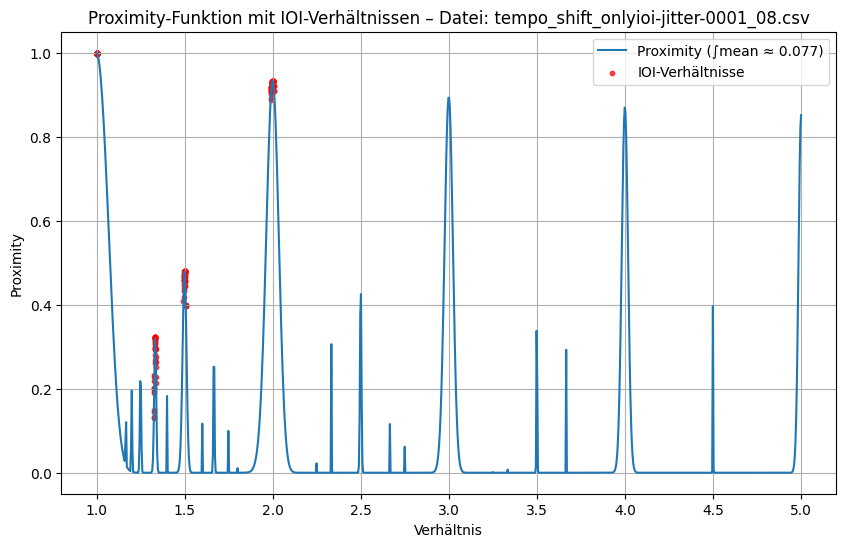

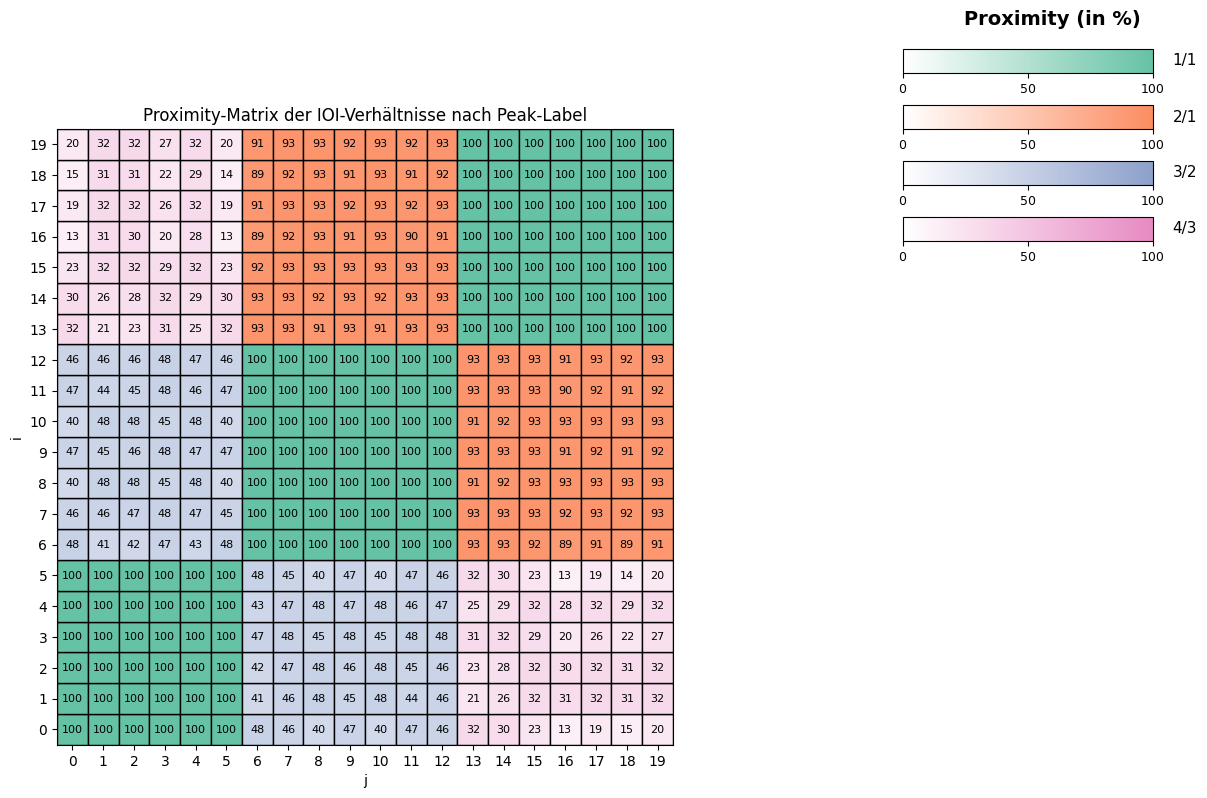

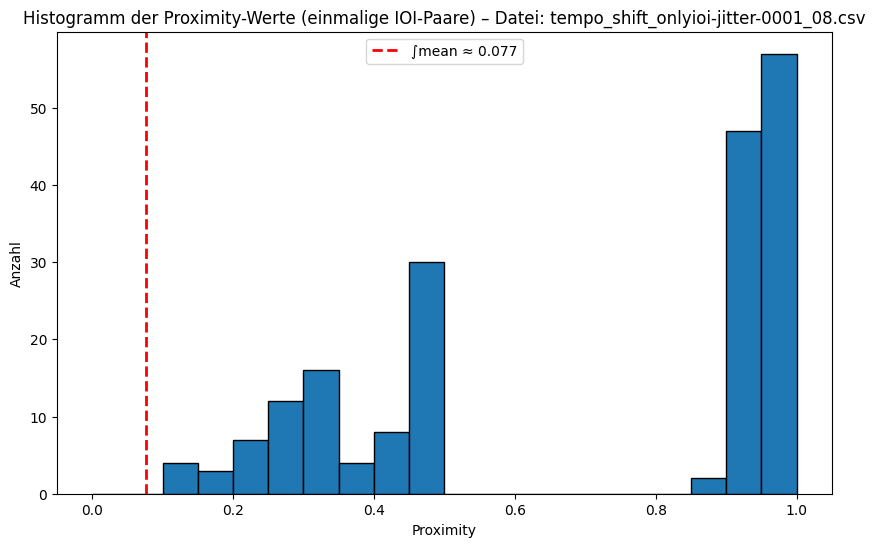

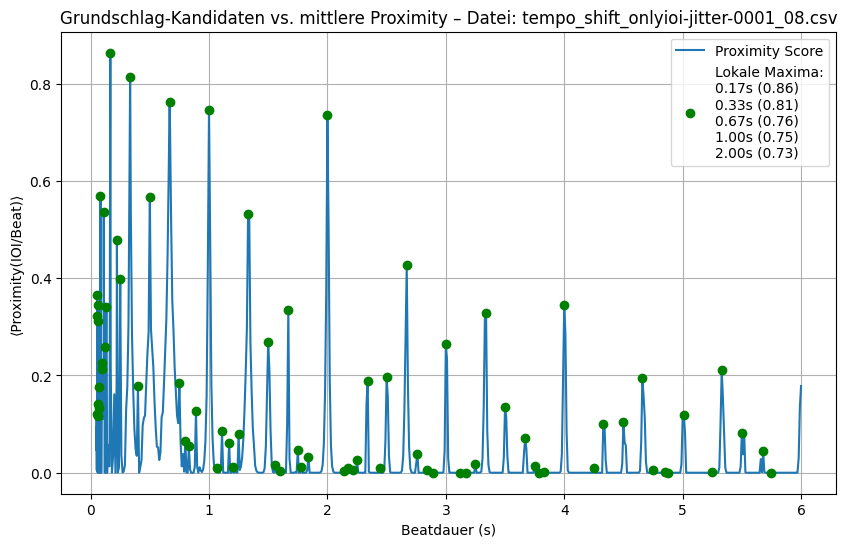

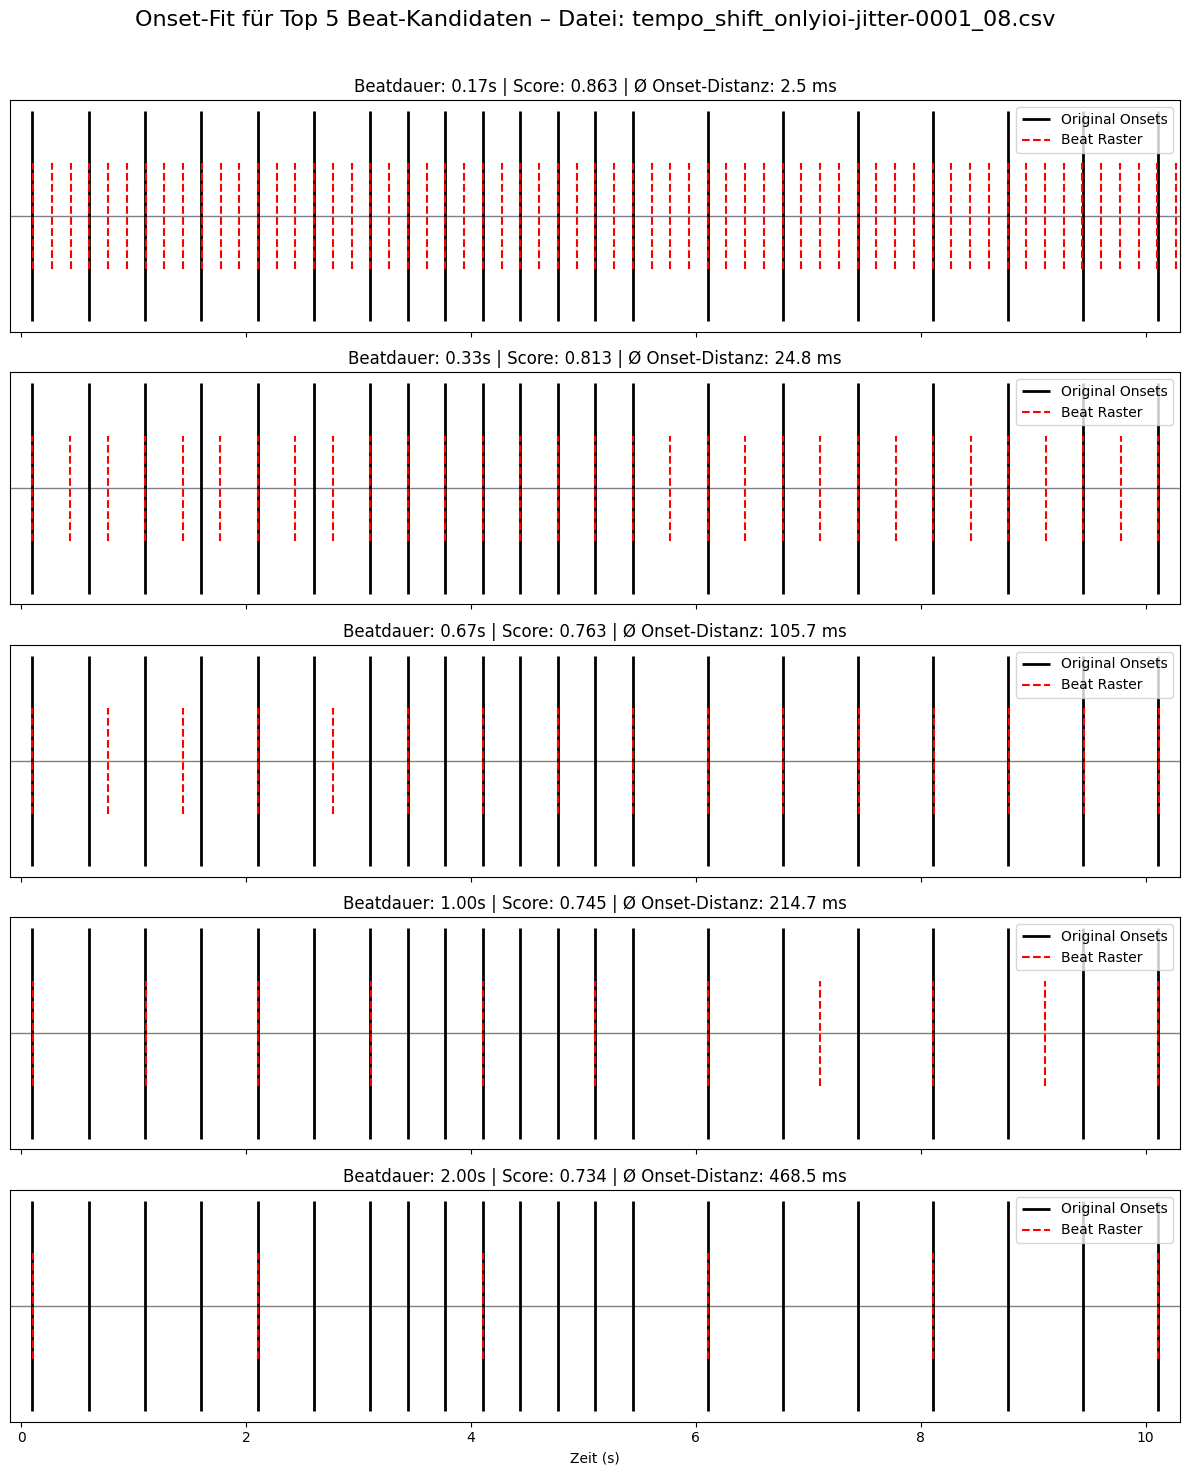


=== Pairwise-DataFrame (Kopf) ===
   i  j     ioi_i     ioi_j     ratio  proximity peak_label ratio_fraction  \
0  0  1  0.501821  0.499597  1.004451   0.997586        1/1              1   
1  0  2  0.501821  0.499753  1.004139   0.997885        1/1              1   
2  0  3  0.501821  0.501014  1.001610   0.999583        1/1              1   
3  0  4  0.501821  0.500025  1.003592   0.998360        1/1              1   
4  0  5  0.501821  0.501864  1.000087   0.999991        1/1              1   

   scaled_value  base_units  approx_ioi  
0             6         1.0    1.442105  
1             6         1.0    1.442105  
2             6         1.0    1.442105  
3             6         1.0    1.442105  
4             6         1.0    1.442105  


In [ ]:
# (also old!!! --> see "Single Sequence Analyisis.ipynb")=== Analyse von IOI-Verhältnissen zur Beat-Detektion ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.integrate import simpson
from scipy.signal import argrelextrema
from fractions import Fraction
from collections import Counter
from math import gcd
from functools import reduce

# =============================
# 1) Proximity-Funktion
# =============================
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    """
    Gibt zurück:
      proximity_max : ndarray wie x (maximale Proximity über alle f)
      peak_indices  : ndarray wie x (Index in 'freqs' des besten f)
      freqs         : ndarray der getesteten f (1..max_freq)
    """
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)  # shape: (num_freqs, *x.shape)
    peak_indices = np.argmax(all_freq_values, axis=0)
    proximity_max = np.max(all_freq_values, axis=0)

    # Normalisierung auf output_max
    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max, peak_indices, freqs

# =============================
# 2) Hilfsfunktionen
# =============================
def generate_beat_candidates_from_iois(iois, min_ioi=0.05, max_ioi=6.0, resolution=0.01, max_denominator=48):
    raster = np.arange(min_ioi, max_ioi + 1e-12, resolution)
    candidates = set(np.round(raster, 6))
    for ioi in iois:
        if ioi < min_ioi or ioi > max_ioi:
            continue
        for denom in range(1, max_denominator + 1):
            beat = ioi / denom
            if min_ioi <= beat <= max_ioi:
                candidates.add(float(Fraction(beat).limit_denominator(1000)))
    for denom in range(1, max_denominator + 1):
        val = 1.0 / denom
        if min_ioi <= val <= max_ioi:
            candidates.add(float(Fraction(val).limit_denominator(1000)))
    return sorted(candidates)

def score_for_beat(beat, iois, params):
    ratios = np.maximum(iois, beat) / np.minimum(iois, beat)
    prox_vals, _, _ = proximity_max_freq(ratios, **params)
    return float(np.mean(prox_vals))

def find_local_maxima(candidates, scores, order=2):
    indices = argrelextrema(np.array(scores), np.greater, order=order)[0]
    return [(candidates[i], scores[i]) for i in indices]

def build_pairwise_proximity_df(iois, params, threshold=0.01):
    """
    Baut einen DataFrame über alle IOI-Paare (nur obere Dreieck):
    Spalten: i, j, ioi_i, ioi_j, ratio (>=1), proximity, peak_label (oder 'Keine Proximity')
    Die peak_label orientiert sich am tatsächlich maximalen f:
      best_f = freqs[peak_idx], dann p = round(ratio*best_f) -> Label = (p/best_f) (gekürzt)
    """
    n = len(iois)
    # Ratio-Matrix (>=1)
    ratios = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j]) for j in range(n)] for i in range(n)])
    prox_max, peak_idx, freqs = proximity_max_freq(ratios, **params)

    rows = []
    for i in range(n):
        for j in range(i + 1, n):
            r = float(ratios[i, j])
            s = float(prox_max[i, j])
            if s > threshold:
                best_f = int(freqs[peak_idx[i, j]])      # 1..max_freq
                p = int(round(r * best_f))               # nächstgelegener Zähler
                frac = Fraction(p, best_f)               # automatisch gekürzt
                label = f"{frac.numerator}/{frac.denominator}"
            else:
                label = "Keine Proximity"

            rows.append({
                "i": i,
                "j": j,
                "ioi_i": float(iois[i]),
                "ioi_j": float(iois[j]),
                "ratio": r,
                "proximity": s,
                "peak_label": label
            })

    df_pairs = pd.DataFrame(rows)
    return df_pairs, ratios, prox_max

# =============================
# 3) Setup: Datei laden
# =============================
filename = "tempo_shift_onlyioi-jitter-0001_08.csv"
base_dir = Path("../data/theoretical_sequences/baseIOI-0.50/20beats")
seq_path = base_dir / filename
if not seq_path.exists():
    raise FileNotFoundError(f"Datei nicht gefunden: {seq_path.resolve()}")

df = pd.read_csv(seq_path)
iois = df["IOI"].dropna().values
onsets = df["onset"].dropna().values

# =============================
# 4) Basis-Tonlänge aus IOI-Verhältnissen
# =============================

# Nur Paare mit Proximity > Threshold
valid_pairs = df_pairs[df_pairs["proximity"] > PAIR_THRESHOLD]

# Häufigkeitstabelle der Verhältnisse
counts = Counter(valid_pairs["peak_label"])
counts.setdefault("Keine Proximity", 0)

# Sortieren nach Bruchwert für bessere Übersicht
sorted_counts = sorted(
    counts.items(),
    key=lambda x: (
        x[0] != "Keine Proximity",
        float(x[0].split('/')[0]) / float(x[0].split('/')[1]) if "/" in x[0] else 0
    )
)

print("=== Verhältnis-Häufigkeiten (über Threshold) ===")
for key, val in sorted_counts:
    print(f"{key}: {val} mal")

# Brüche aus den Labels erzeugen
fractions = []
for label, count in sorted_counts:
    if label != "Keine Proximity":
        num, denom = map(int, label.split("/"))
        for _ in range(count):  # jeden Bruch nach Häufigkeit einfügen
            fractions.append(Fraction(num, denom))

# kleinster gemeinsamer Nenner (LCM) aller Brüche
denominators = [frac.denominator for frac in fractions]
lcm_denominator = np.lcm.reduce(denominators)
print(f"\nKleinster gemeinsamer Nenner aller Brüche: {lcm_denominator}")

# alle Brüche auf denselben Nenner bringen
scaled_values = [frac.numerator * (lcm_denominator // frac.denominator) for frac in fractions]
print(f"Skalierte Werte auf LCM: {scaled_values[:20]} ... (insgesamt {len(scaled_values)} Werte)")

# Basis-Tonlänge als Mittelwert auf dieser kleinsten Einheit
base_length_units = np.mean(scaled_values)
base_ioi = base_length_units / lcm_denominator
print(f"\n=== Basis-Tonlänge (s) ===")
print(f"Basis-Tonlänge: {base_ioi:.4f} s")

# =============================
# 5) Analyse von IOI-Paaren zur Bestimmung der Basis-IOI
# =============================

# Parameter für Threshold
PAIR_THRESHOLD = 0.01  # anpassen falls nötig

# 1) Paare bilden & Proximity + Peak berechnen
n = len(iois)
pair_records = []
for i in range(n):
    for j in range(i + 1, n):  # obere Dreiecksmatrix: i<j
        ioi_i, ioi_j = iois[i], iois[j]
        ratio = max(ioi_i, ioi_j) / min(ioi_i, ioi_j)
        prox_val, peak_idx, freqs = proximity_max_freq([ratio], **params)
        prox_val = float(prox_val[0])
        if prox_val > PAIR_THRESHOLD:
            best_f = int(freqs[peak_idx[0]])
            p = int(round(ratio * best_f))
            frac = Fraction(p, best_f)
            peak_label = f"{frac.numerator}/{frac.denominator}"
        else:
            peak_label = "Keine Proximity"
        pair_records.append({
            "i": i,
            "j": j,
            "ioi_i": ioi_i,
            "ioi_j": ioi_j,
            "ratio": ratio,
            "prox_value": prox_val,
            "peak_label": peak_label
        })

df_pairs_filtered = pd.DataFrame(pair_records)

# 2) Nur Paare mit Proximity > Threshold
valid_pairs = df_pairs_filtered[df_pairs_filtered["prox_value"] > PAIR_THRESHOLD]

# 3) Häufigkeit der Peak-Labels ausgeben
counts = Counter(valid_pairs["peak_label"])
print("\n=== Verhältnis-Häufigkeiten (über Threshold) ===")
for label, count in counts.items():
    print(f"{label}: {count} mal")

# 4) Brüche aus Peak-Labels erzeugen und skalierte Werte berechnen
fractions = []
for label, count in counts.items():
    if label != "Keine Proximity":
        num, denom = map(int, label.split("/"))
        for _ in range(count):
            fractions.append(Fraction(num, denom))

if len(fractions) > 0:
    denominators = [frac.denominator for frac in fractions]
    lcm_denominator = np.lcm.reduce(denominators)
    scaled_values = [frac.numerator * (lcm_denominator // frac.denominator) for frac in fractions]

    # 5) Basis-IOI berechnen
    base_ioi = np.mean([ (iois[0] / scaled_values[0]) * sv for sv in scaled_values ])  # Mittelwert über alle Skalenwerte
    print(f"\n=== Basis-IOI (best-fit) ===")
    print(f"Basis-IOI: {base_ioi:.4f} s")
else:
    print("\nKeine gültigen Peak-Labels gefunden – Basis-IOI konnte nicht bestimmt werden.")


# =============================
# 6) Beatkandidaten scoren
# =============================
beat_candidates = generate_beat_candidates_from_iois(iois)
scores = [score_for_beat(beat, iois, params) for beat in beat_candidates]
local_maxima = find_local_maxima(beat_candidates, scores, order=2)
local_maxima_top5 = sorted(local_maxima, key=lambda x: -x[1])[:5]

# =============================
# 7) Plots
# =============================

# === 1) Proximity-Funktion + Punkte ===
plt.figure(figsize=(10, 6))
x_range = np.linspace(1, 5, 1000)
y_curve = np.array([proximity_max_freq(x, **params)[0] for x in x_range])  # nur Proximity
mean_prox = simpson(y_curve, x=x_range) / (x_range[-1] - x_range[0])
plt.plot(x_range, y_curve, label=f"Proximity (∫mean ≈ {mean_prox:.3f})")
plt.scatter(df_pairs["ratio"].values, df_pairs["proximity"].values, s=10, alpha=0.7, color="red", label="IOI-Verhältnisse")
plt.title(f"Proximity-Funktion mit IOI-Verhältnissen – Datei: {filename}")
plt.xlabel("Verhältnis")
plt.ylabel("Proximity")
plt.legend()
plt.grid(True)
plt.show()

# === 2) Recurrence-Plot (Peak-Label-Farbskalen) ===

# === all_pairs_df erstellen ===
records = []
n = len(iois)
for i in range(n):
    for j in range(n):
        ratio = max(iois[i], iois[j]) / min(iois[i], iois[j])
        prox_val = proximity_max_freq([ratio], **params)[0]
        if prox_val > PAIR_THRESHOLD:
            frac = Fraction(ratio).limit_denominator(params["max_freq"])
            peak_label = f"{frac.numerator}/{frac.denominator}"
        else:
            peak_label = "Keine Proximity"
        records.append({
            "i": i,
            "j": j,
            "ioi_i": iois[i],
            "ioi_j": iois[j],
            "ratio": ratio,
            "prox_value": prox_val,
            "peak_label": peak_label
        })
all_pairs_df = pd.DataFrame.from_records(records)

# === Plot vorbereiten ===
pivot_vals = all_pairs_df.pivot(index="i", columns="j", values="prox_value") * 100
pivot_labels = all_pairs_df.pivot(index="i", columns="j", values="peak_label")

unique_labels = sorted(set(all_pairs_df["peak_label"]))
palette = sns.color_palette("Set2", len(unique_labels))
label_to_cmap = {}
for label, base_color in zip(unique_labels, palette):
    white_rgb = (1, 1, 1)
    cmap_colors = [white_rgb, base_color]
    label_to_cmap[label] = plt.cm.colors.LinearSegmentedColormap.from_list(f"{label}_cmap", cmap_colors)

# === Plot zeichnen ===
fig, ax = plt.subplots(figsize=(10, 8))
for (i, j), val in np.ndenumerate(pivot_vals.values):
    label = pivot_labels.iloc[i, j]
    cmap = label_to_cmap[label]
    color = cmap(val / 100)  # Wert zwischen 0 und 1
    rect = plt.Rectangle([j, i], 1, 1, facecolor=color, edgecolor='black')
    ax.add_patch(rect)
    val_float = float(val[0])     # explizit erstes Element wählen # von ndarray zu Skalar
    ax.text(j + 0.5, i + 0.5, f"{int(round(val_float))}", ha='center', va='center', fontsize=8)

# Achsen von 0 aufsteigend
ax.set_xlim(0, n)
ax.set_ylim(0, n)
ax.set_aspect('equal')
ax.set_xticks(np.arange(n) + 0.5)
ax.set_yticks(np.arange(n) + 0.5)
ax.set_xticklabels(range(n))
ax.set_yticklabels(range(n))
ax.set_xlabel("j")
ax.set_ylabel("i")
ax.set_title("Proximity-Matrix der IOI-Verhältnisse nach Peak-Label")

# Nur Verhältnisse mit Proximity > 0 anzeigen
legend_labels = [lab for lab in unique_labels if lab != "Keine Proximity"]

# Position für die Legende rechts neben dem Plot
legend_x_start = 1.05
legend_y_start = 0.95
cbar_height = 0.03
spacing = 0.04

# Überschrift für alle Skalen
fig.text(legend_x_start + 0.15, legend_y_start + 0.06, "Proximity (in %)", 
         ha="center", fontsize=14, fontweight="bold")

for idx, label in enumerate(legend_labels):
    cmap = label_to_cmap[label]
    norm = plt.Normalize(vmin=0, vmax=100)

    y_pos = legend_y_start - idx * (cbar_height + spacing)

    # Größerer horizontaler Farbbalken
    cbar_ax = fig.add_axes([legend_x_start, y_pos, 0.25, cbar_height])  
    cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                      cax=cbar_ax, orientation="horizontal")
    cb.set_ticks([0, 50, 100])
    cb.ax.tick_params(labelsize=9)

    # Verhältnis rechts vom Balken
    fig.text(legend_x_start + 0.27, y_pos + cbar_height / 2, label,
             va="center", fontsize=11)

plt.show()

# === 3) Histogramm der Proximity-Werte ===
plt.figure(figsize=(10, 6))
triu_idx = np.triu_indices_from(proximity_mat, k=1)
proximity_unique = proximity_mat[triu_idx]
plt.hist(proximity_unique, bins=20, range=(0, 1), edgecolor='black')
plt.axvline(mean_prox, color='red', linestyle='--', linewidth=2, label=f"∫mean ≈ {mean_prox:.3f}")
plt.title(f"Histogramm der Proximity-Werte (einmalige IOI-Paare) – Datei: {filename}")
plt.xlabel("Proximity")
plt.ylabel("Anzahl")
plt.legend()
plt.show()

# === 4) Beat-Kandidaten & Score ===
plt.figure(figsize=(10, 6))
plt.plot(beat_candidates, scores, label="Proximity Score")
for beat, score in local_maxima:
    plt.plot(beat, score, 'o', color='green')
top_labels = [f"{beat:.2f}s ({score:.2f})" for beat, score in local_maxima_top5]
plt.plot([], [], 'o', color='green', label="Lokale Maxima:\n" + "\n".join(top_labels))
plt.title(f"Grundschlag-Kandidaten vs. mittlere Proximity – Datei: {filename}")
plt.xlabel("Beatdauer (s)")
plt.ylabel("⟨Proximity(IOI/Beat)⟩")
plt.legend()
plt.grid(True)
plt.show()

# =============================
# 8) Top-5 Onset-Fit
# =============================
def find_best_phase_shift(onsets, beat_period, resolution=0.001):
    first_onset = onsets[0]
    last_onset = onsets[-1]
    search_range = np.arange(0, beat_period, resolution)
    best_shift = 0.0
    best_score = float('inf')
    for shift in search_range:
        beats = np.arange(first_onset + shift, last_onset + beat_period, beat_period)
        dists = np.min(np.abs(onsets[:, None] - beats[None, :]), axis=1)
        score = np.mean(dists)
        if score < best_score:
            best_score = score
            best_shift = float(shift)
    return best_shift

def match_beats_to_onsets(onsets, beat_period, phase_shift=0.0):
    first_onset = onsets[0]
    last_onset = onsets[-1]
    beat_times = np.arange(first_onset + phase_shift, last_onset + beat_period, beat_period)
    dists = np.min(np.abs(onsets[:, None] - beat_times[None, :]), axis=1)
    return {
        "beat_times": beat_times,
        "mean_onset_dist": float(np.mean(dists)),
        "std_onset_dist": float(np.std(dists))
    }

n_top = len(local_maxima_top5)
if n_top > 0:
    fig2, axes2 = plt.subplots(n_top, 1, figsize=(12, 3 * n_top), sharex=True)
    fig2.suptitle(f"Onset-Fit für Top {n_top} Beat-Kandidaten – Datei: {filename}", fontsize=16)
    if n_top == 1:
        axes2 = [axes2]
    for idx, (beat, score) in enumerate(local_maxima_top5):
        ax = axes2[idx]
        best_shift = find_best_phase_shift(onsets, beat)
        stats = match_beats_to_onsets(onsets, beat, phase_shift=best_shift)
        ax.axhline(0, color='gray', linewidth=1)
        ax.vlines(onsets, -0.2, 0.2, color='black', linewidth=2, label='Original Onsets')
        ax.vlines(stats["beat_times"], -0.1, 0.1, color='red', linestyle='--', label='Beat Raster')
        title = (
            f"Beatdauer: {beat:.2f}s | Score: {score:.3f} | "
            f"Ø Onset-Distanz: {stats['mean_onset_dist']*1000:.1f} ms"
        )
        ax.set_title(title)
        ax.set_yticks([])
        ax.set_xlim(onsets[0] - 0.2, onsets[-1] + 0.2)
        ax.legend(loc='upper right')
    plt.xlabel("Zeit (s)")
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
else:
    print("\nKeine lokalen Maxima gefunden — überspringe Onset-Fit Visualisierung.")

# Optional: DataFrame kurz inspizieren
print("\n=== Pairwise-DataFrame (Kopf) ===")
print(df_pairs.head())


**Vergleich unterschiedlicher rhythmischer Sequenzen:**
Für eine Reihe synthetisch generierter Sequenzen aus dem Dataset *synthetic_sequences_20beats* wurden alle 
IOI-Verhältnisse berechnet, die Proximity-Werte ermittelt und die oberen Dreiecksmatrizen (ohne Diagonale) extrahiert.
Diese wurden anschließend nach Sequenztyp (z. B. "accelerando", "heterochron", "tempo_shift") gruppiert und in einem
Boxplot visualisiert.

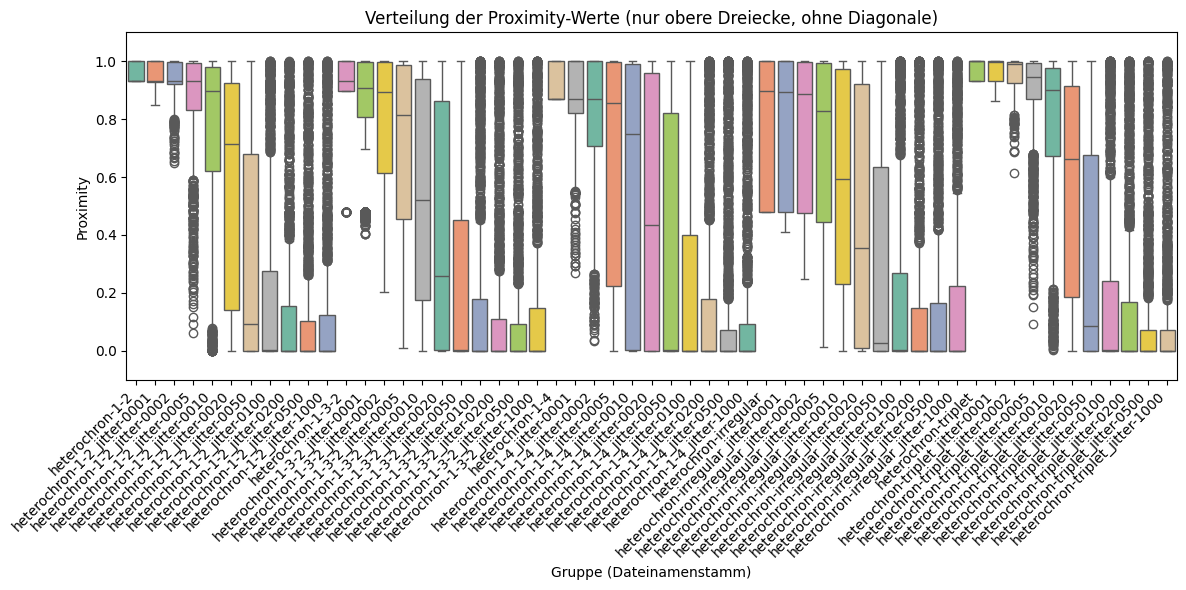

In [40]:
# Analysis of Proximity Values from Synthetic 20-Beats Sequences
# Boxplot of Proximity Values for Each Group

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from pathlib import Path

# === Pfad zur 20-Beats Sequenz-Ordner ===
data_dir = Path("../data/theoretical_sequences/baseIOI-0.50/20beats")
all_csv_files = list(data_dir.glob("*.csv"))

# === Nur Dateien einlesen, deren Name mit bestimmten Gruppen-Präfixen beginnt ===
gruppen_prefixe = ["heterochron-1-2", "heterochron-1-3-2", "heterochron-1-4", "heterochron-irregular", "heterochron-triplet"]  # <- hier anpassen

all_csv_files = [
    f for f in data_dir.glob("*.csv")
    if any(f.name.startswith(prefix) for prefix in gruppen_prefixe)
]

# === Container für Ergebnisse ===
all_results = []

# === Funktion zur Gruppierung aus Dateinamen extrahieren ===
def extract_group_name(filename):
    # Entferne Index vor ".csv", z.B. "_04.csv"
    return re.sub(r"_\d+(?=\.csv)", "", filename).replace(".csv", "")

# === Analyse-Funktion wiederverwenden ===
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    all_freq_values = []
    for freq in range(1, max_freq + 1):
        weight = 1 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)
        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness
        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        cos_term_normalized = cos_term / peak_value
        val = weight * cos_term_normalized / (x ** decay)
        all_freq_values.append(val)
    result = np.maximum.reduce(all_freq_values)
    max_at_norm_x = np.max([
        (1 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in range(1, max_freq + 1)
    ])
    return result / max_at_norm_x * output_max

# === Haupt-Loop über alle Dateien ===
for file_path in all_csv_files:
    try:
        df = pd.read_csv(file_path)
        iois = df["IOI"].dropna().values
        if len(iois) < 2:
            continue  # überspringen, wenn zu wenig Daten

        ratios = np.array([[max(x, y) / min(x, y) for x in iois] for y in iois])
        proximity = proximity_max_freq(
            ratios,
            sharpness_base=10.0,
            sharpness_growth=2.0,
            decay=0.1,
            max_freq=4,
            weight_exponent=1.0,
            freq_sharpness_exp=1.0,
            norm_x=1.0,
            output_max=1.0
        )

        # Nur oberes Dreieck ohne Diagonale nehmen
        upper_triangle_values = proximity[np.triu_indices_from(proximity, k=1)]

        # Gruppe extrahieren
        group_name = extract_group_name(file_path.name)

        # Ergebnis speichern
        for val in upper_triangle_values:
            all_results.append({
                "group": group_name,
                "proximity": val
            })

    except Exception as e:
        print(f"Fehler bei Datei {file_path.name}: {e}")

# === In DataFrame umwandeln ===
results_df = pd.DataFrame(all_results)
results_df["group"] = pd.Categorical(results_df["group"], categories=sorted(results_df["group"].unique()), ordered=True)

# === Plot: Boxplot pro Gruppe ===
plt.figure(figsize=(12, 6))
sns.boxplot(data=results_df, x="group", y="proximity", hue="group", palette="Set2", legend=False)
plt.xticks(rotation=45, ha="right")
plt.ylim(-0.1, 1.1)
plt.title("Verteilung der Proximity-Werte (nur obere Dreiecke, ohne Diagonale)")
plt.xlabel("Gruppe (Dateinamenstamm)")
plt.ylabel("Proximity")
plt.tight_layout()
plt.show()


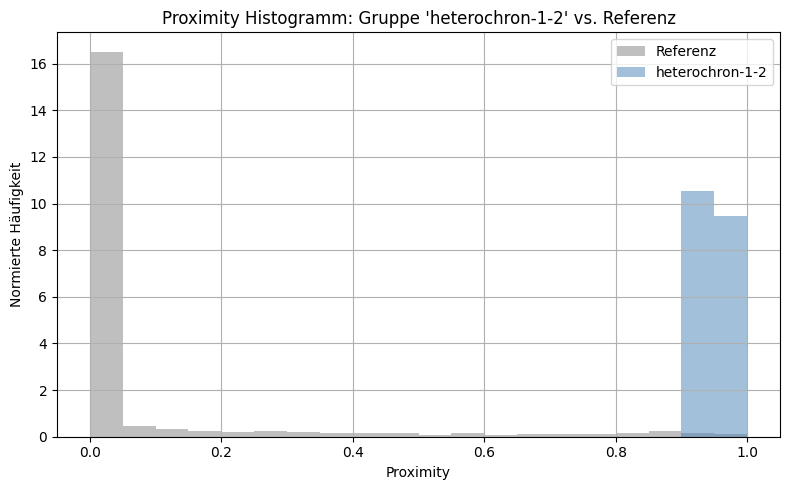

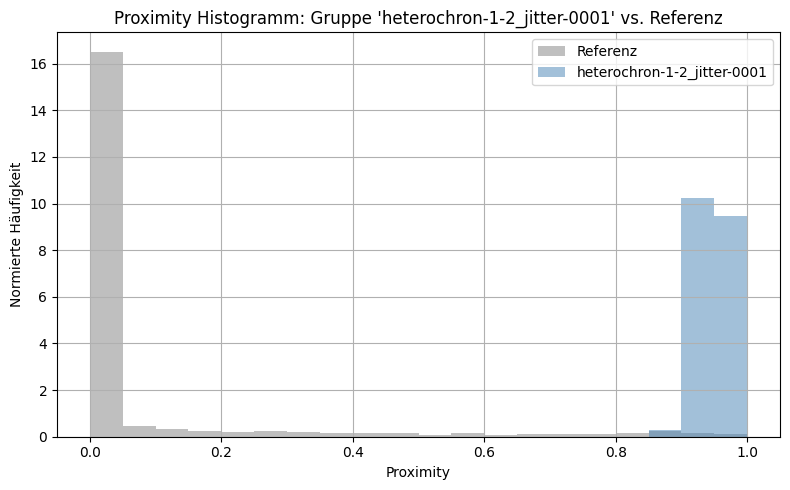

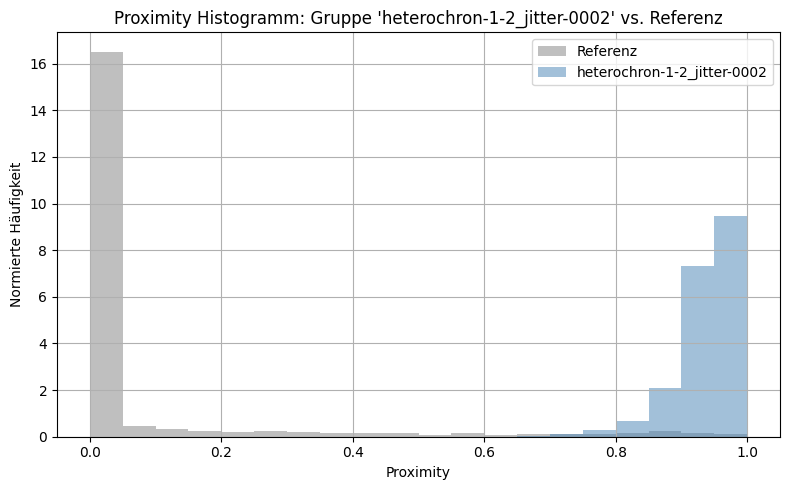

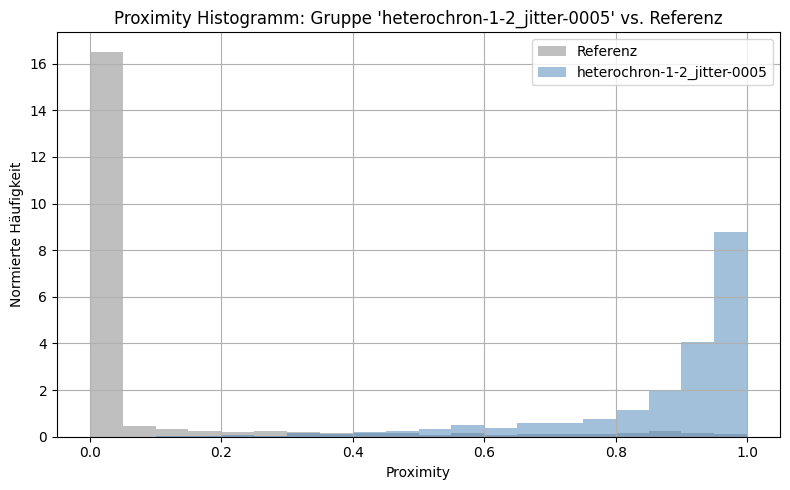

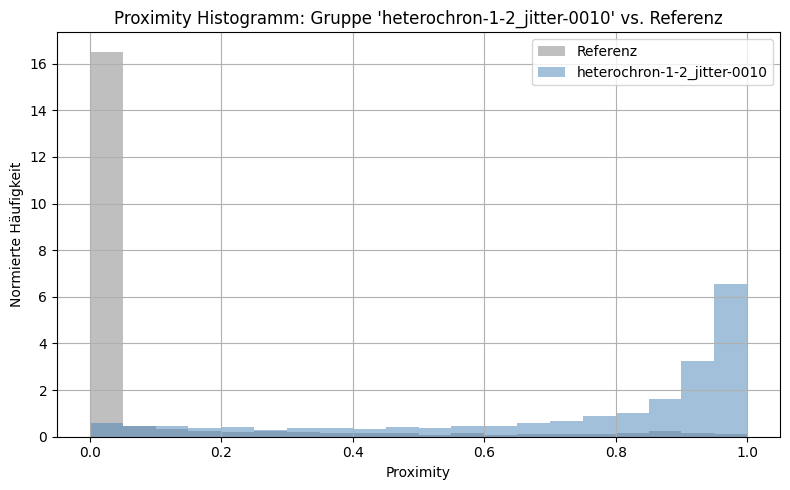

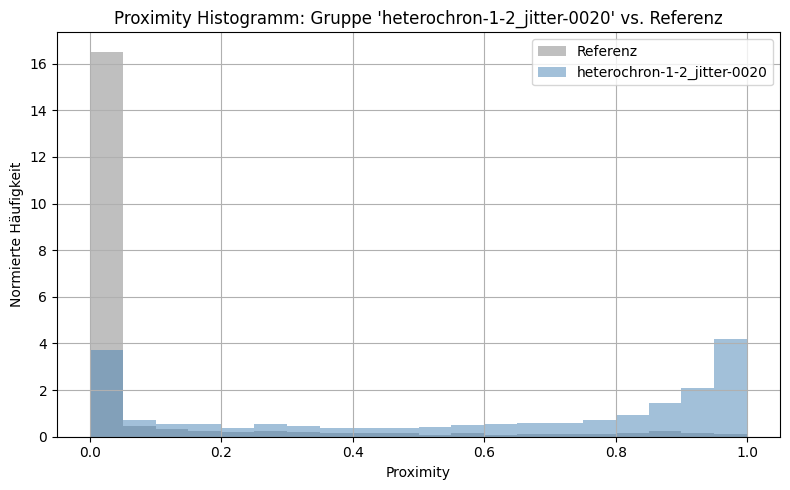

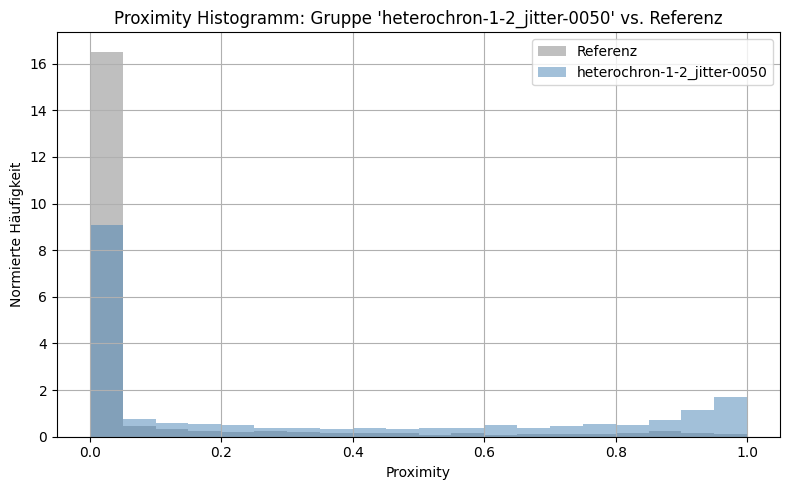

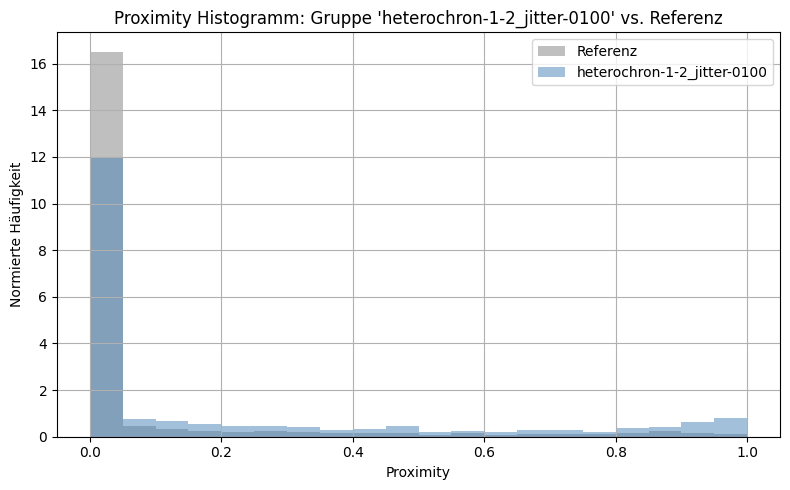

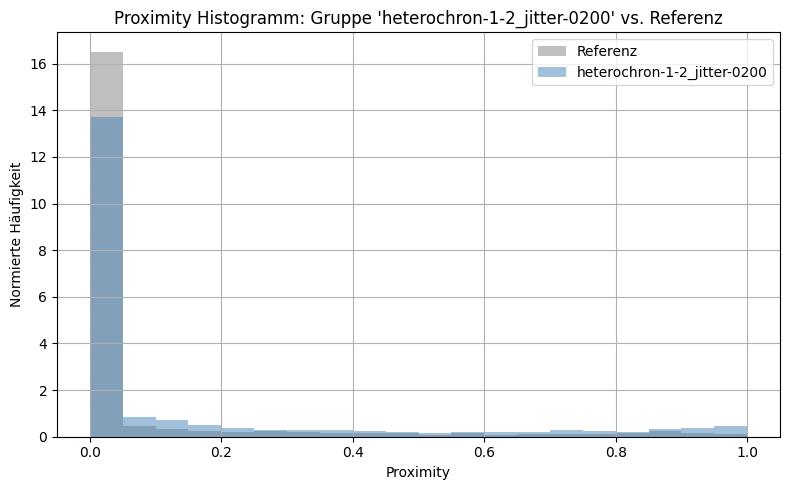

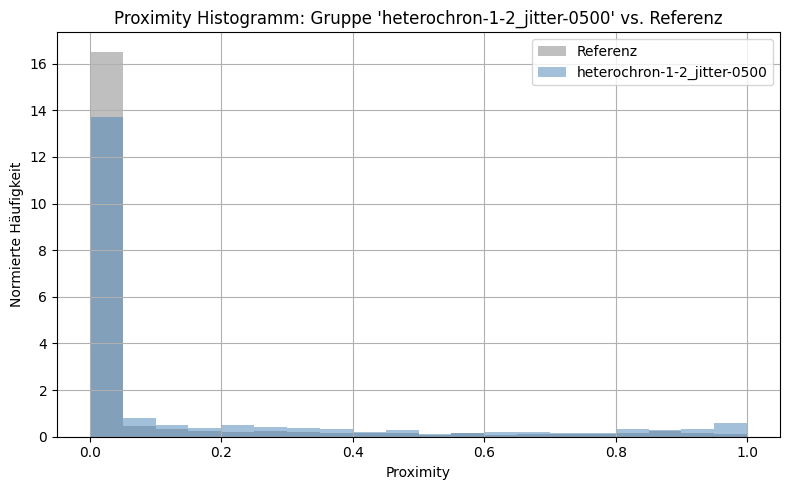

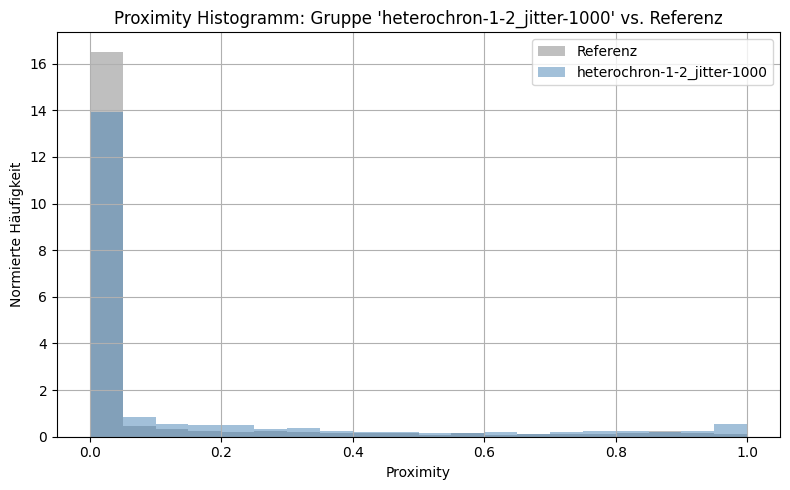

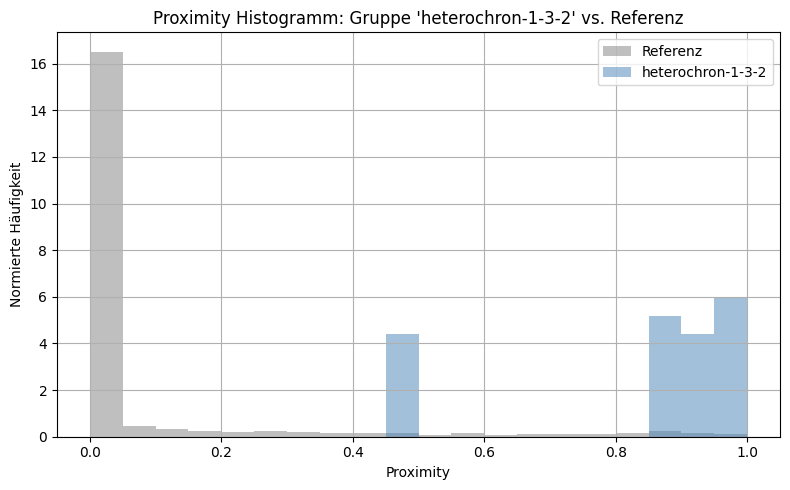

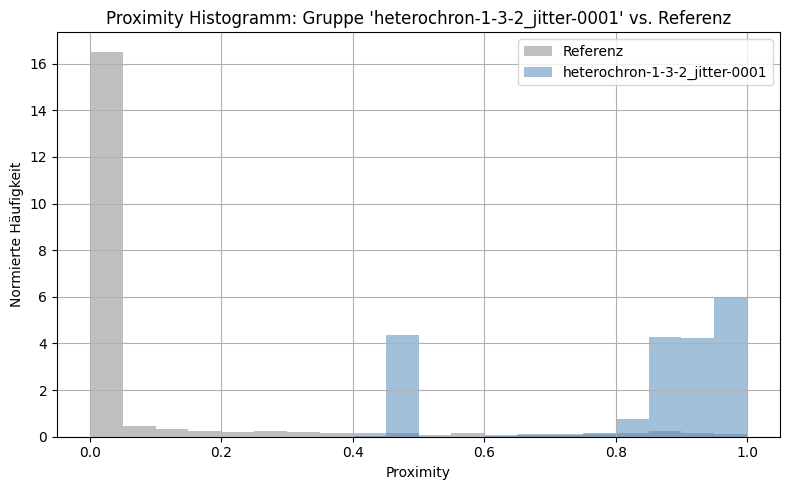

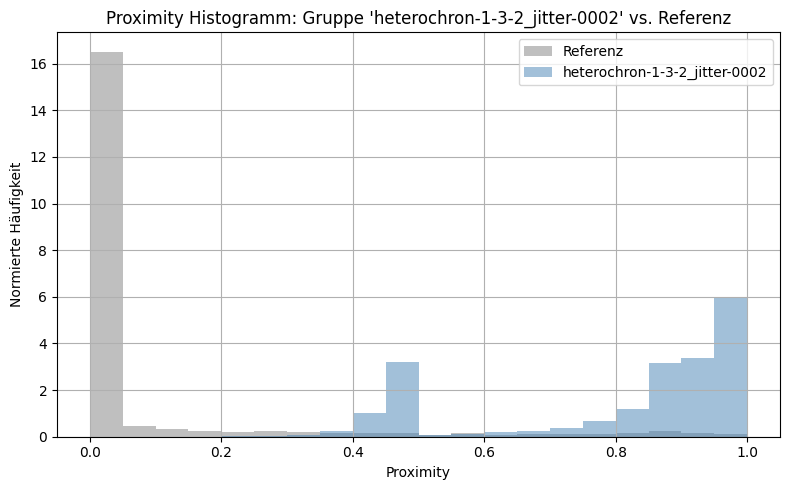

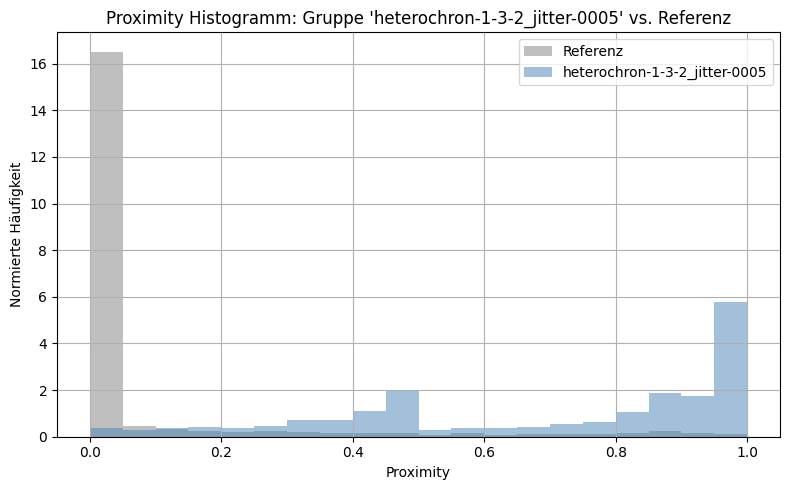

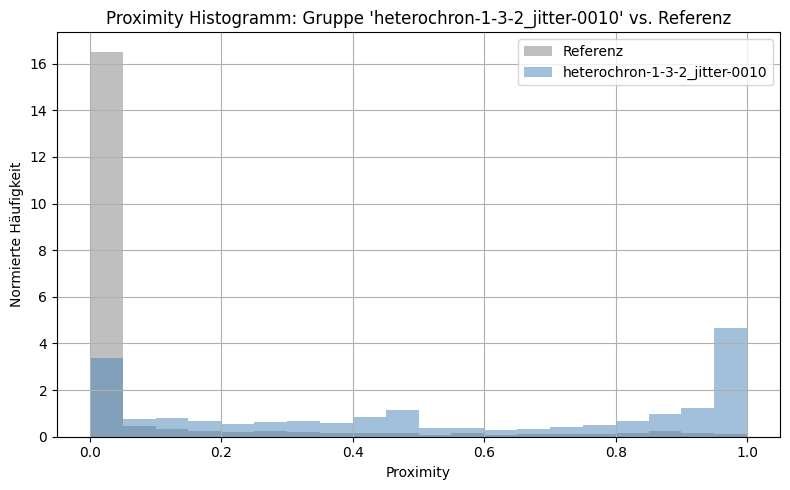

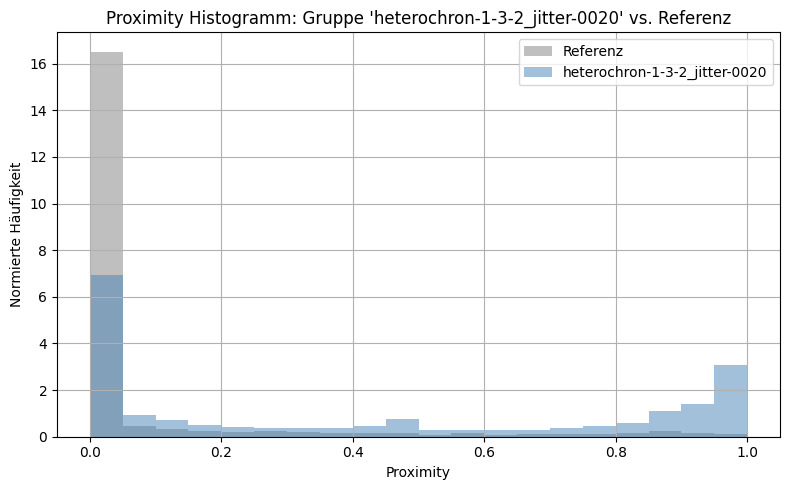

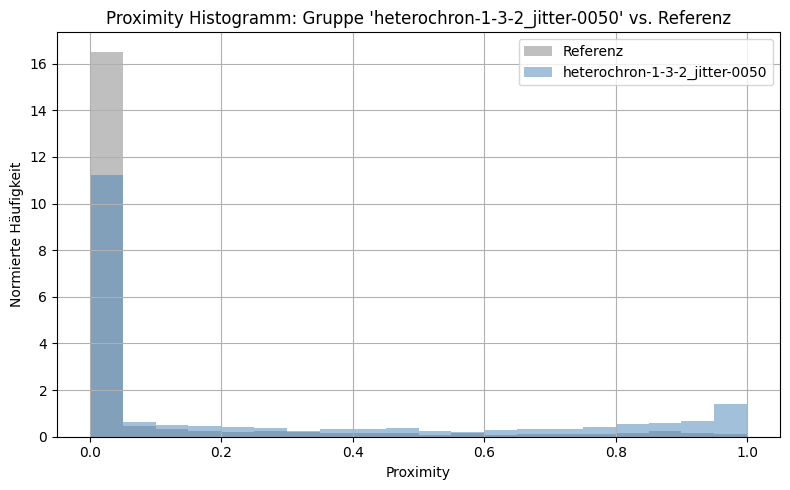

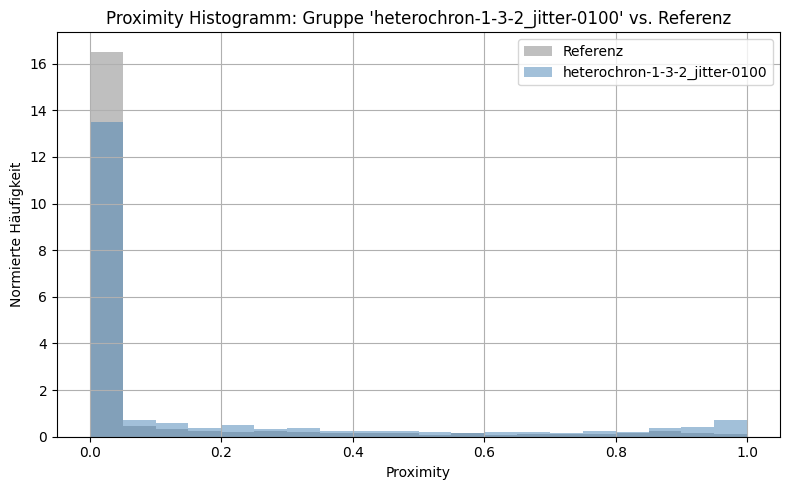

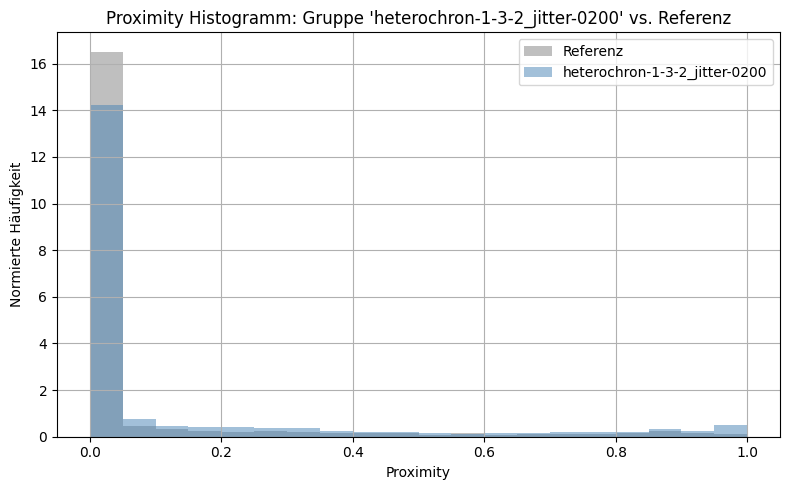

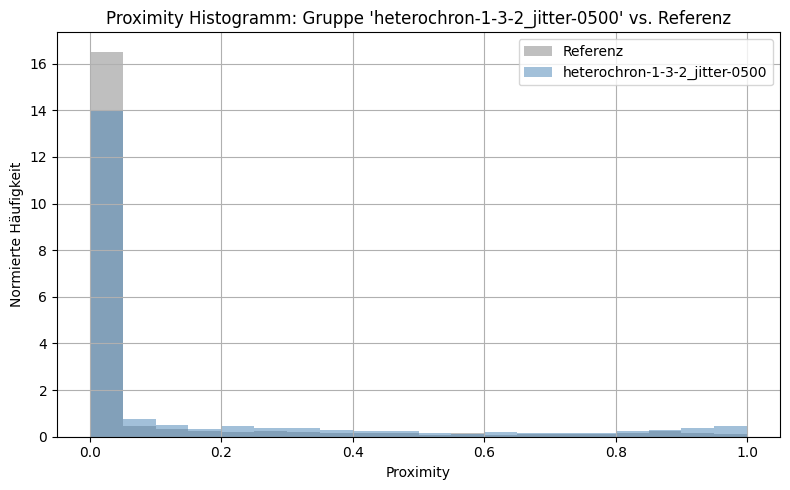

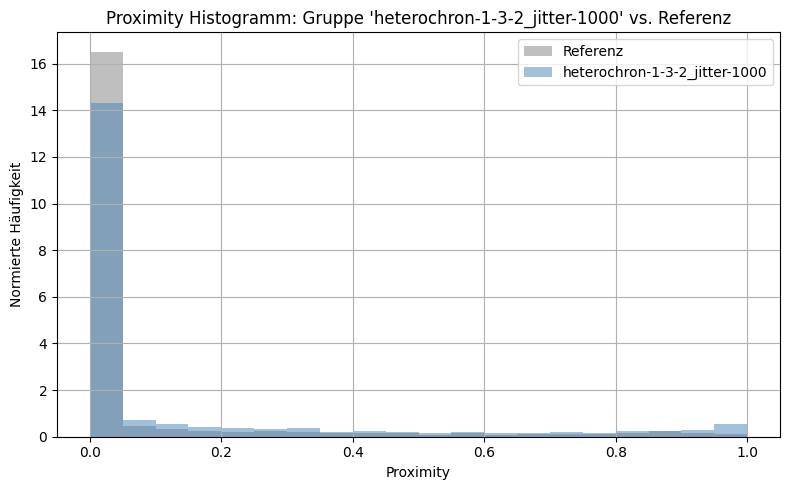

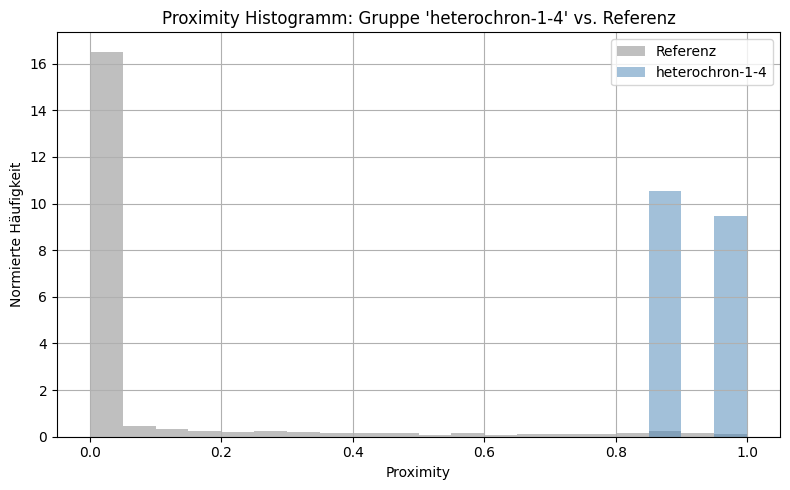

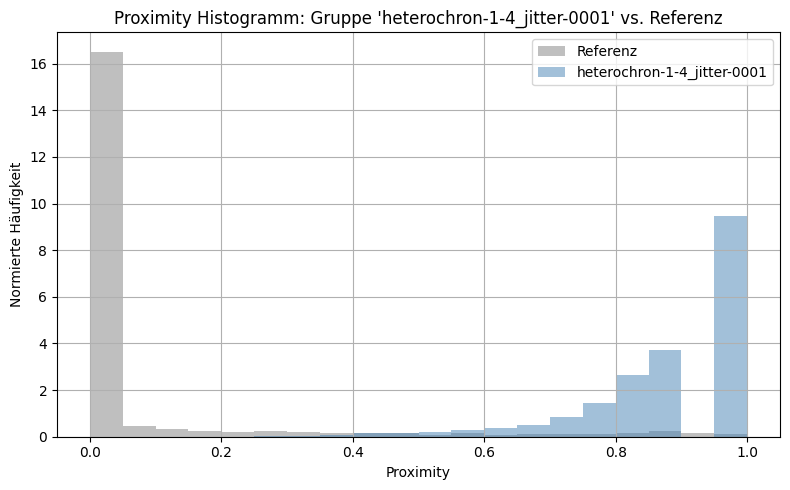

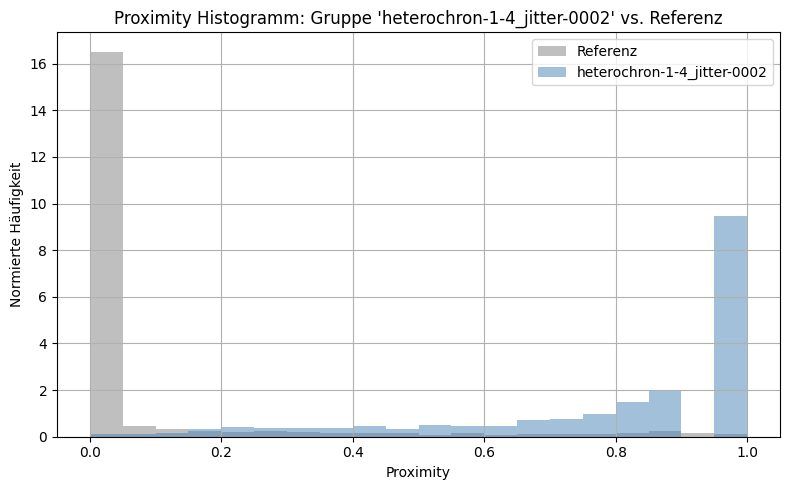

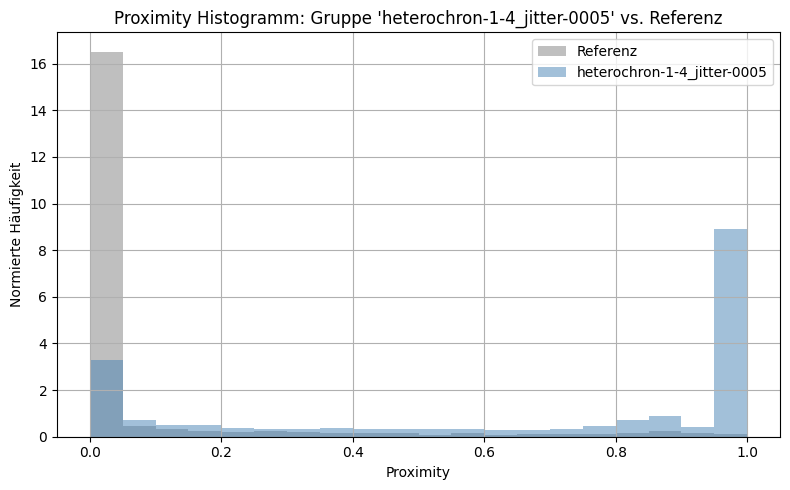

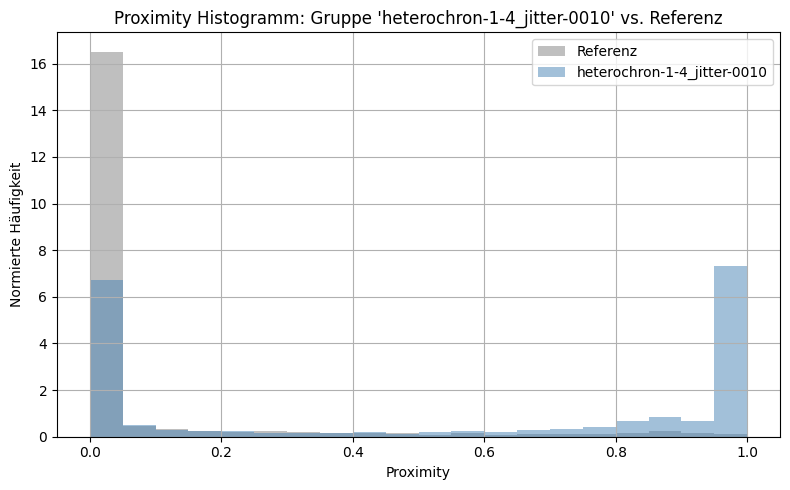

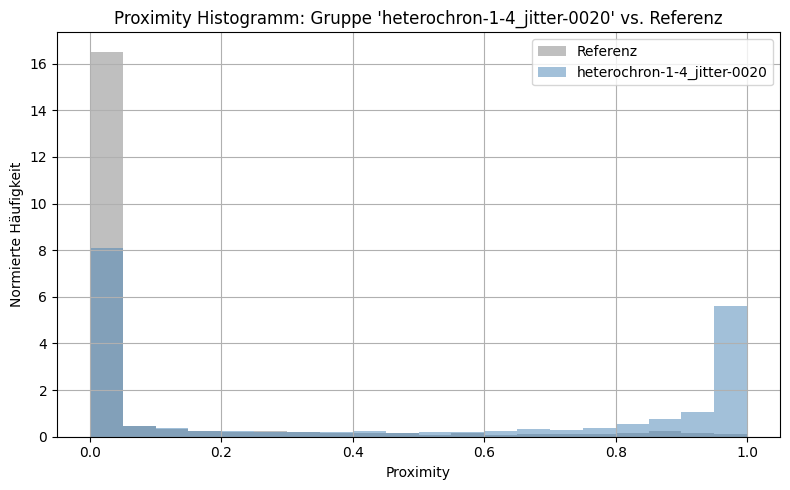

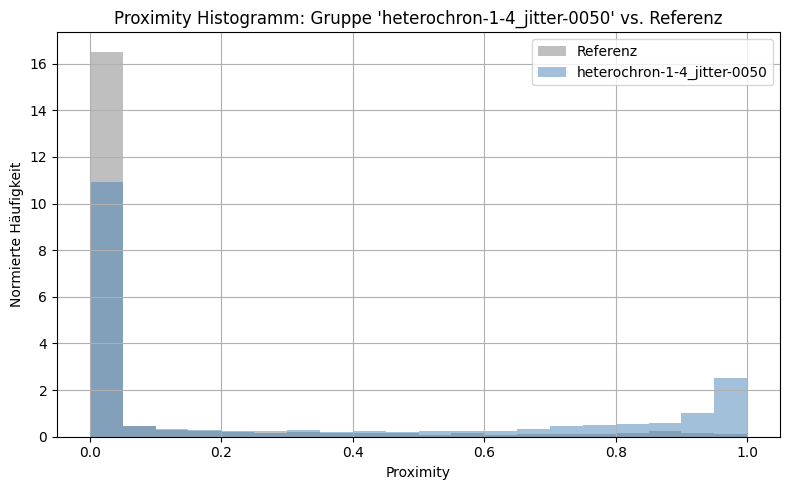

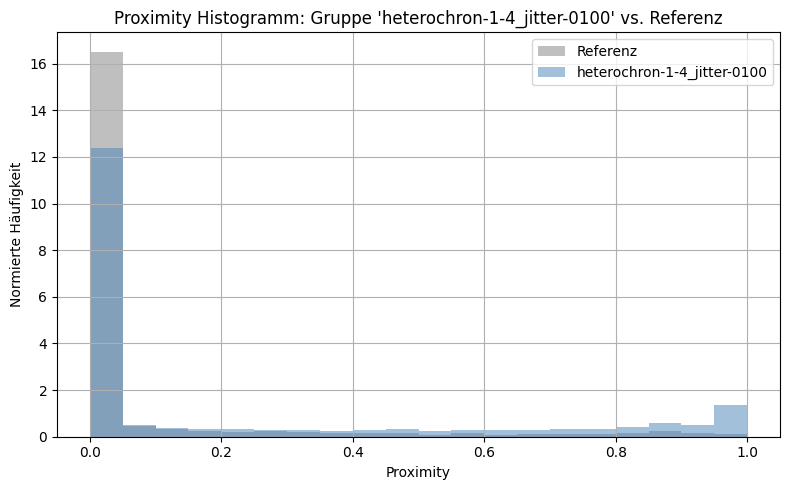

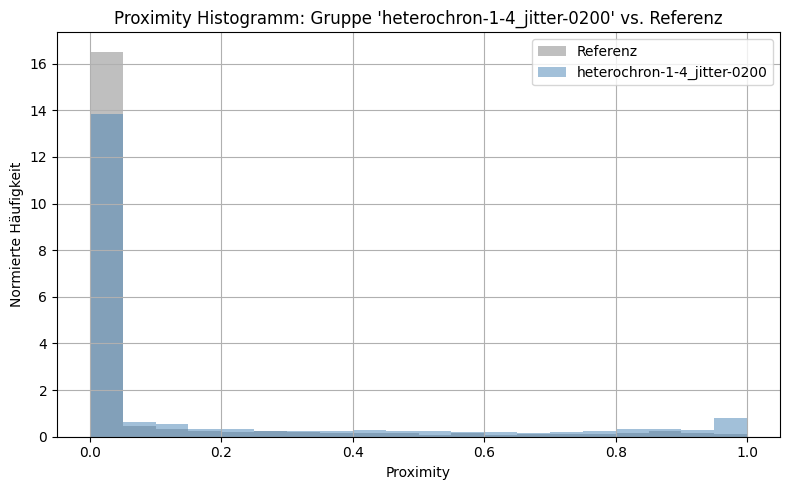

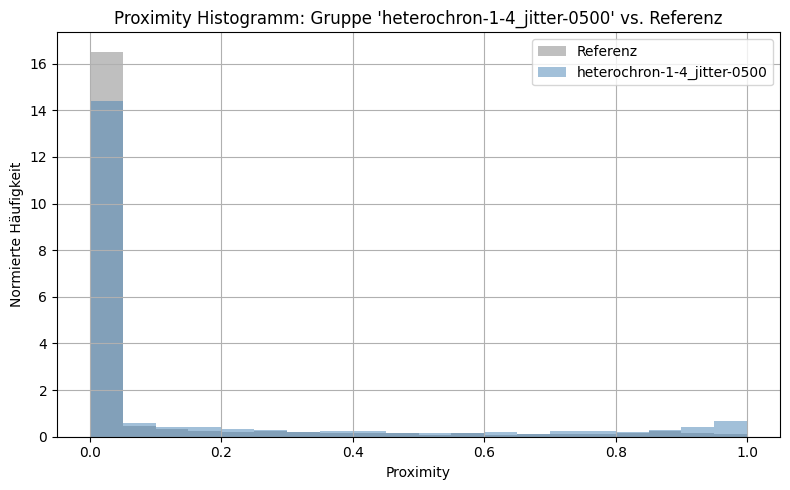

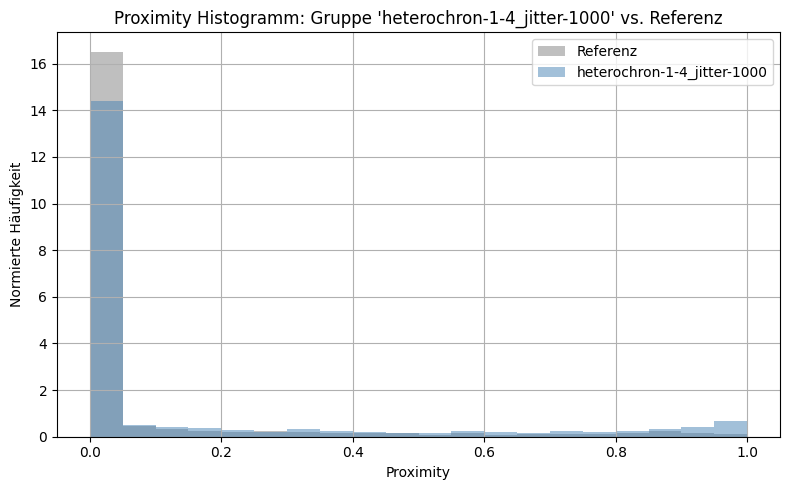

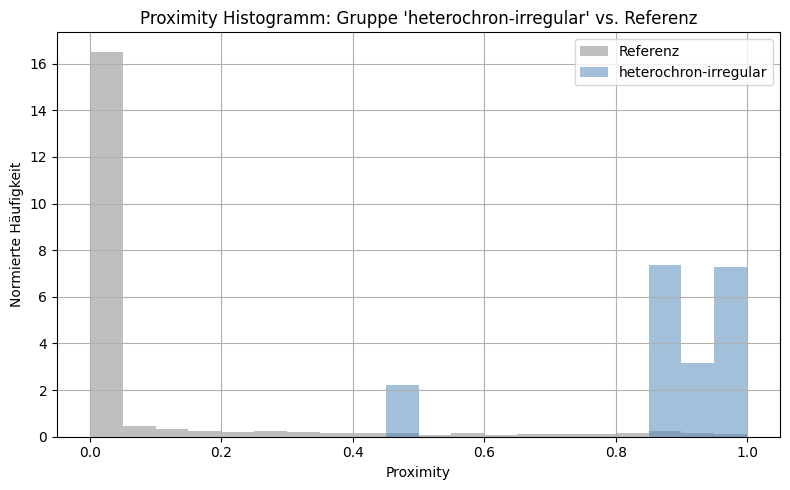

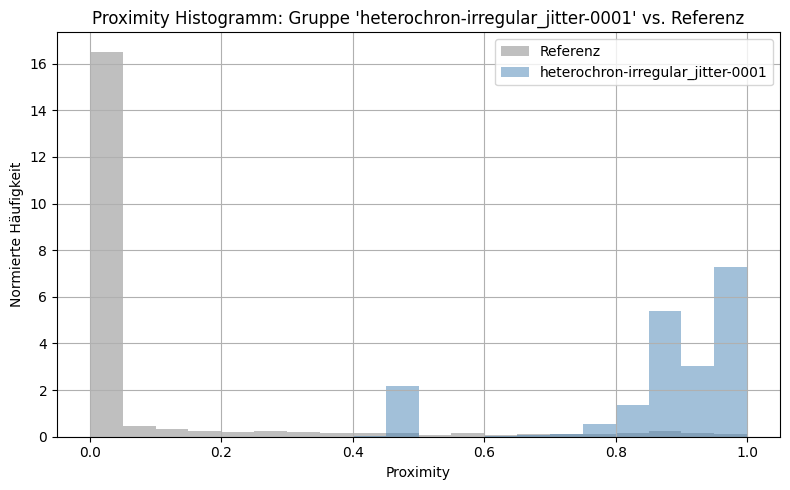

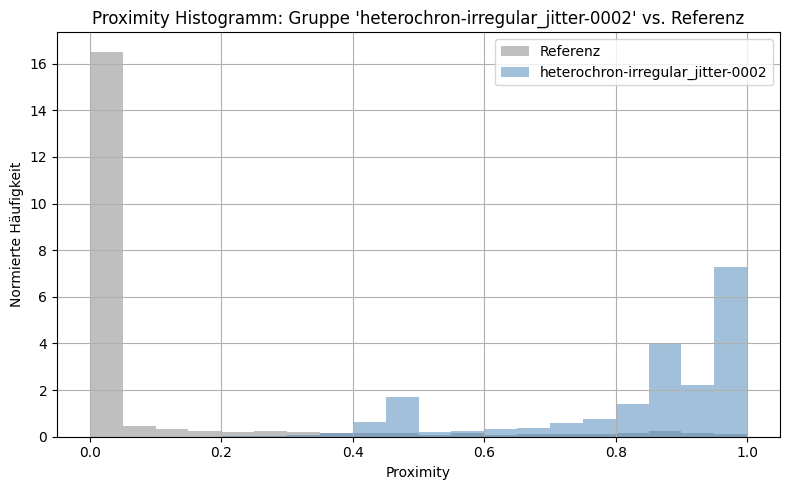

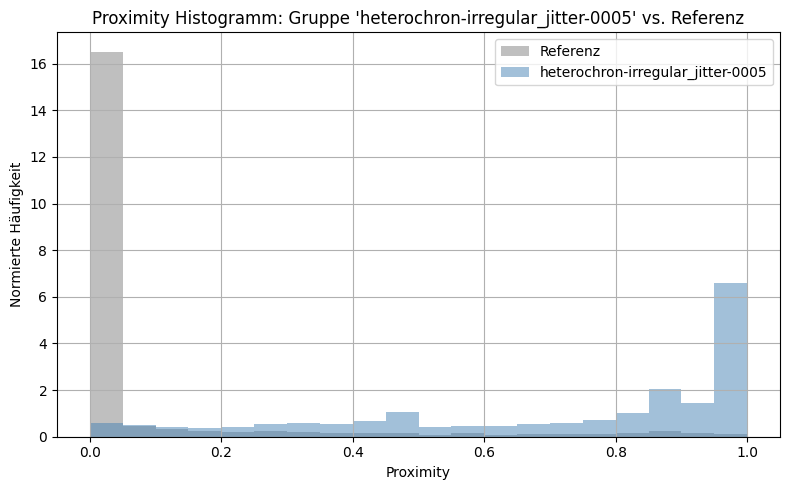

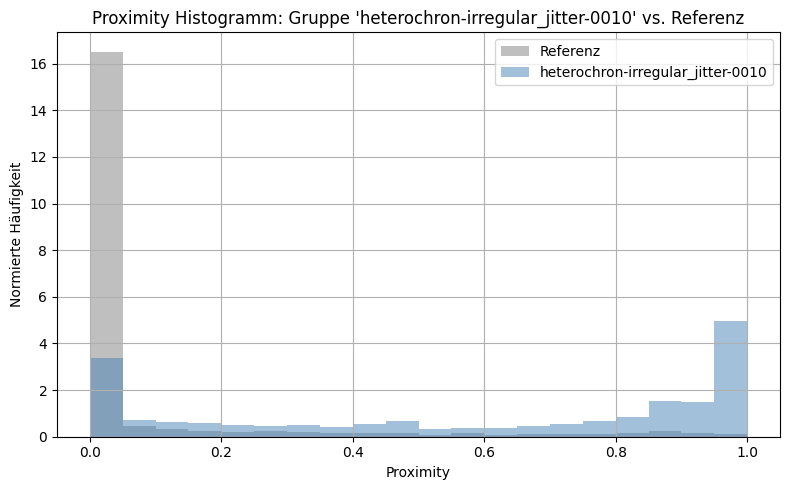

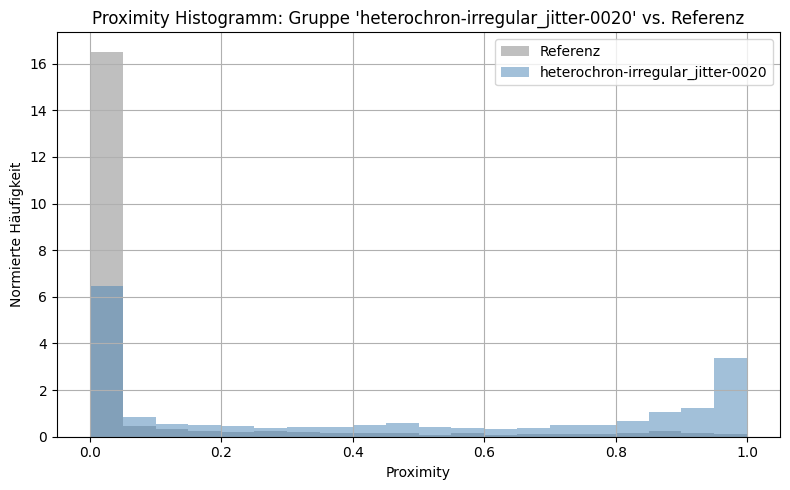

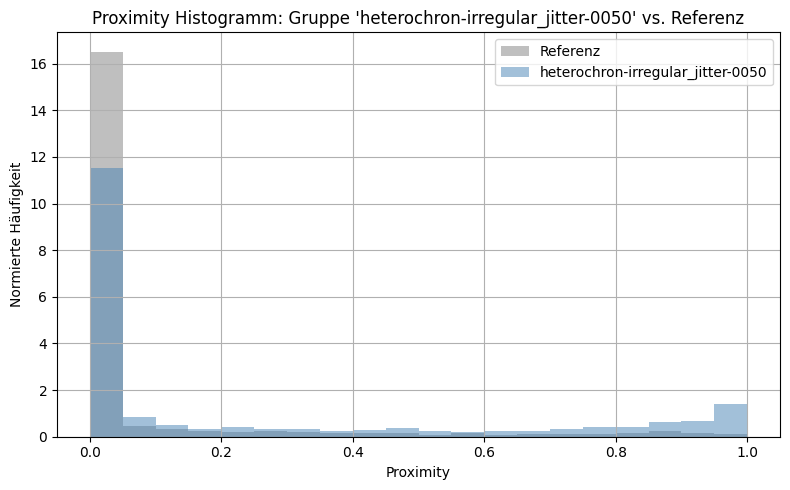

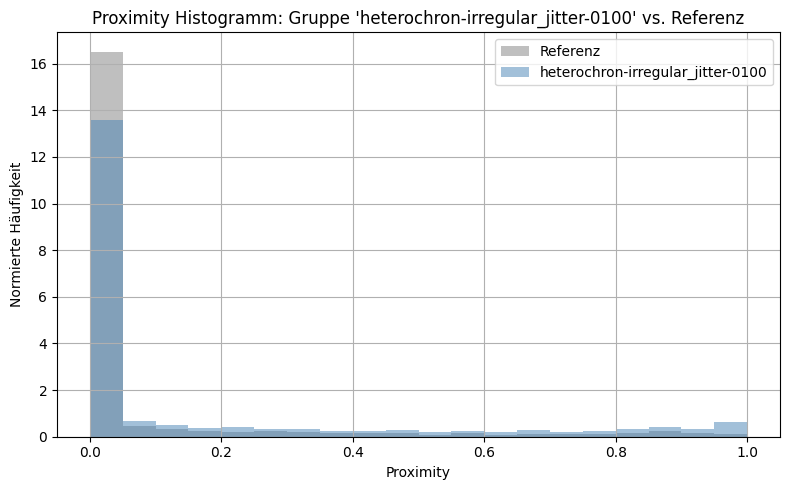

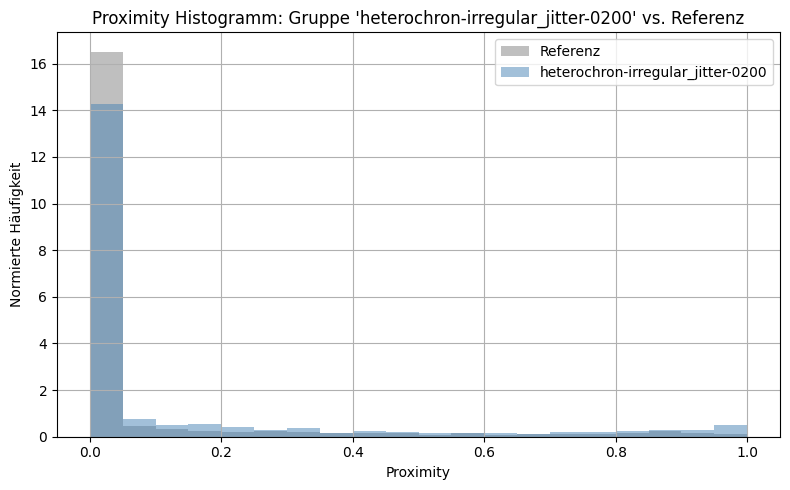

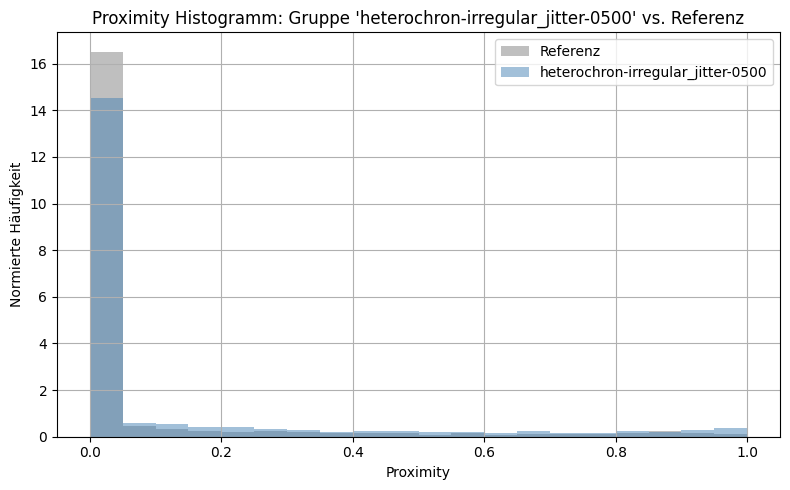

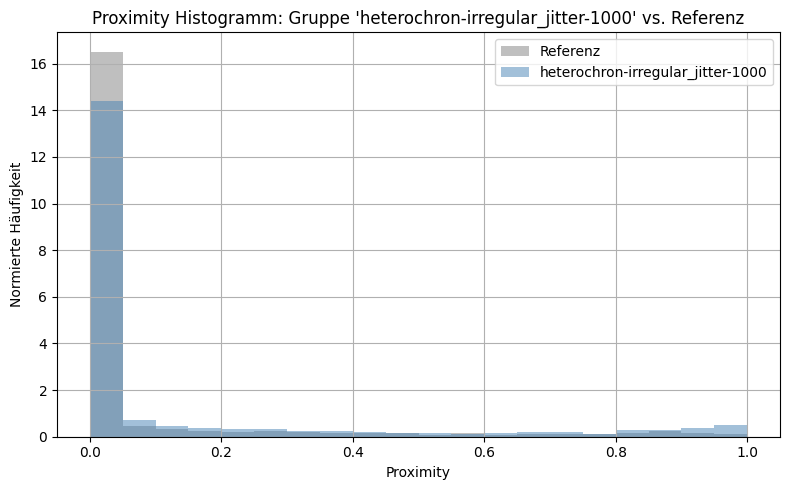

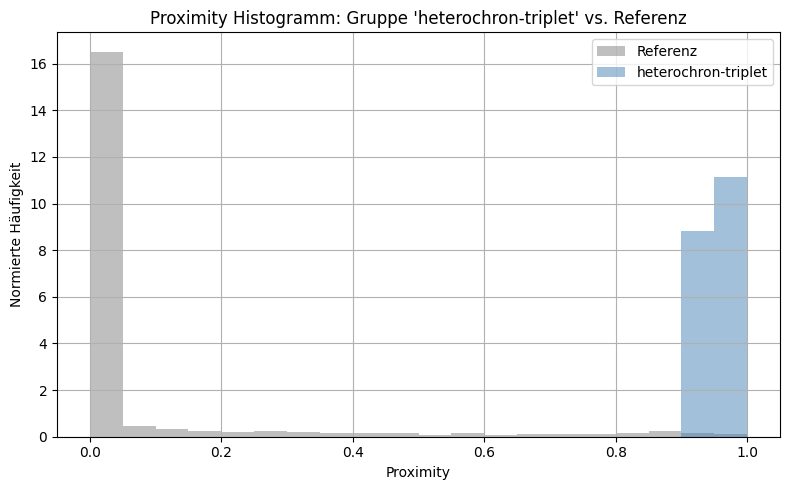

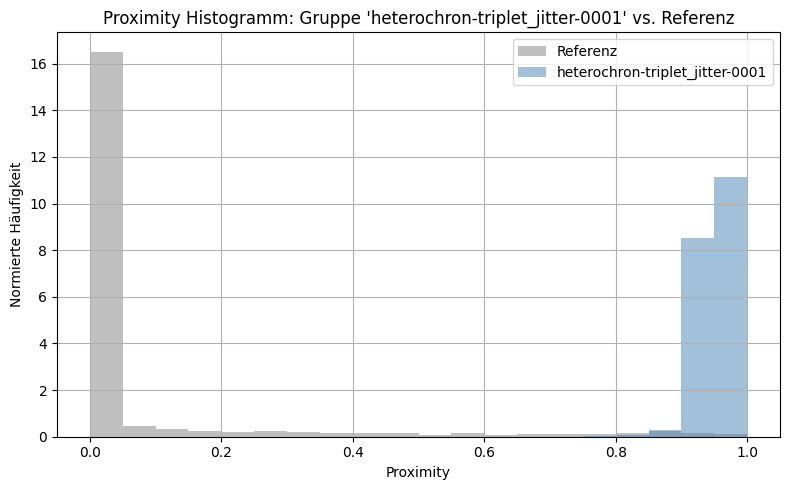

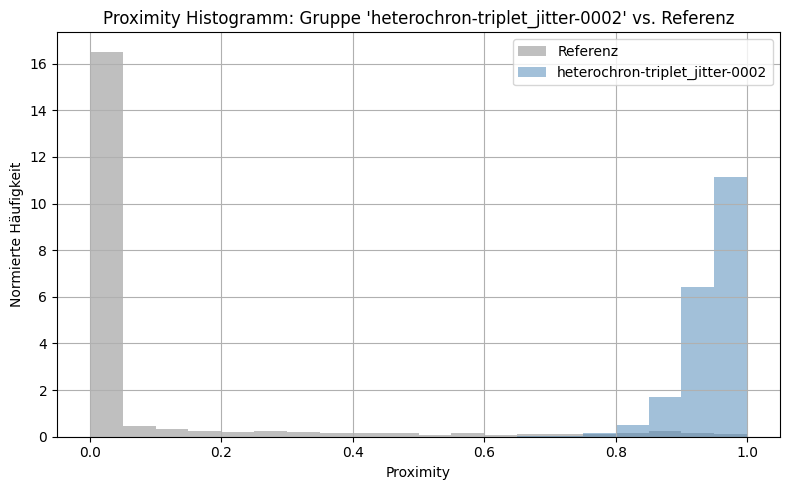

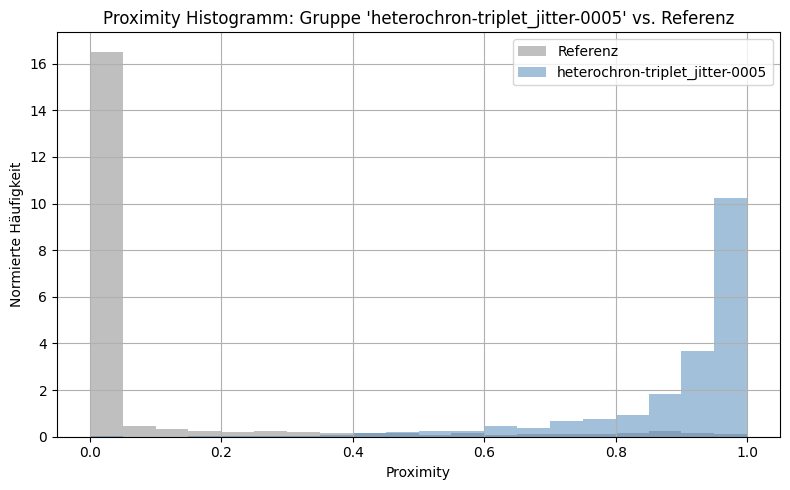

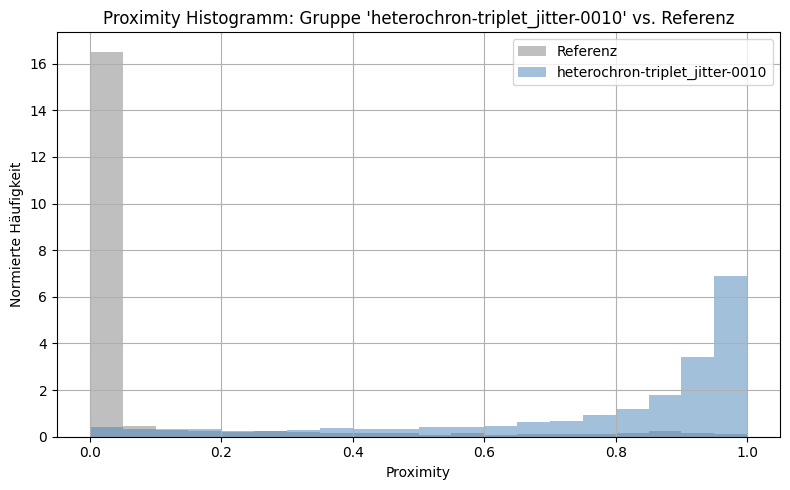

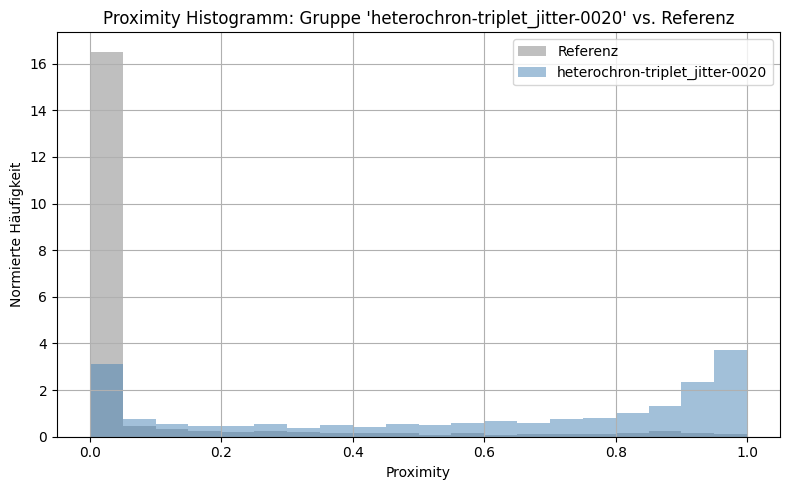

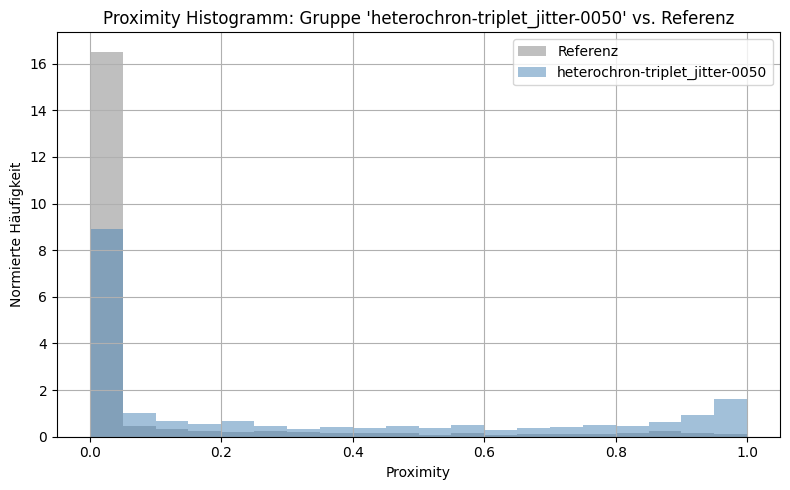

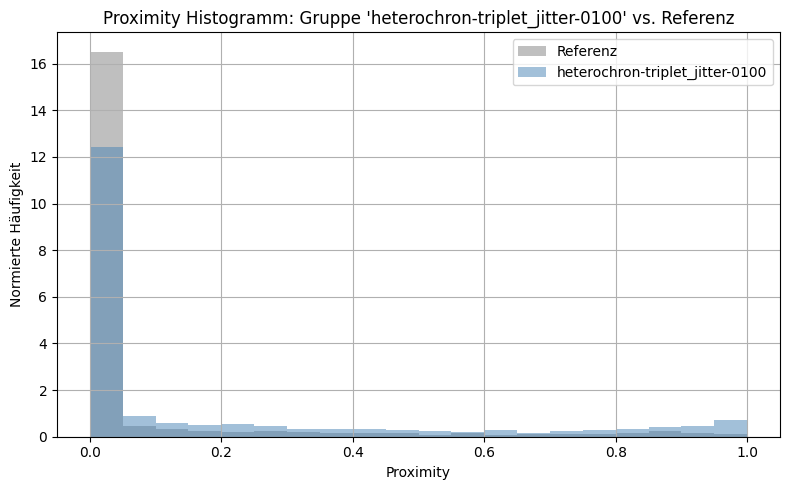

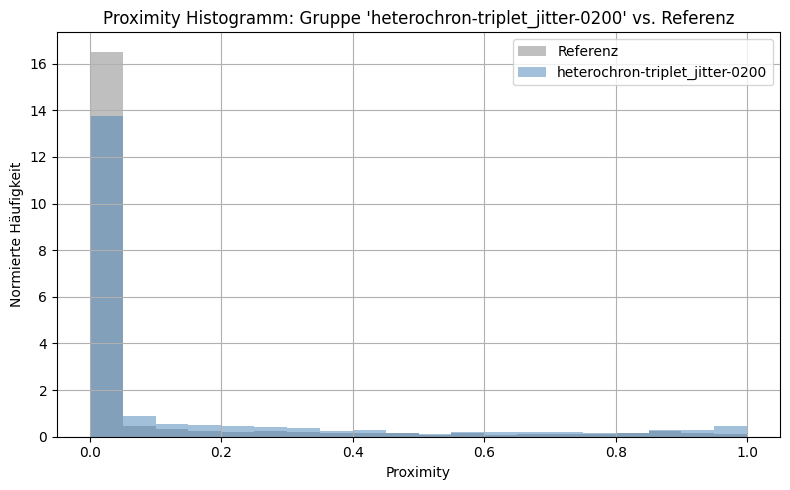

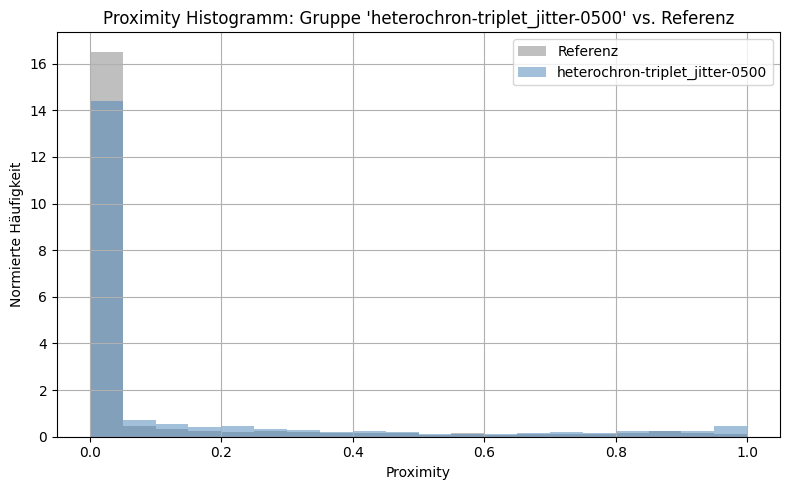

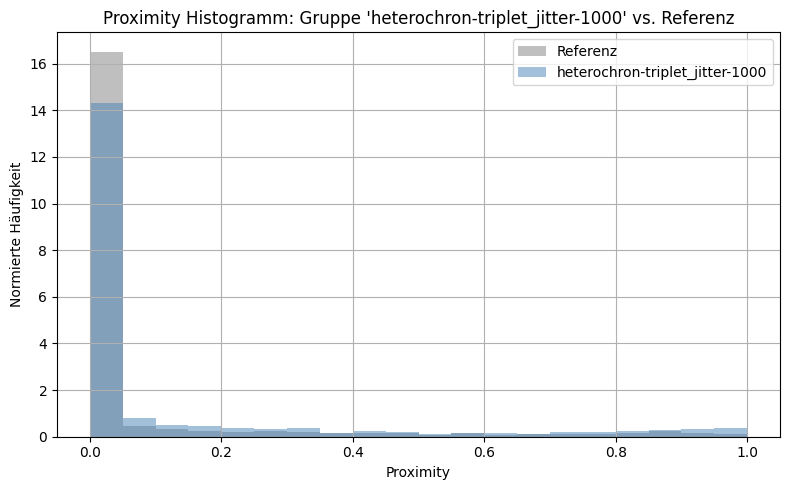

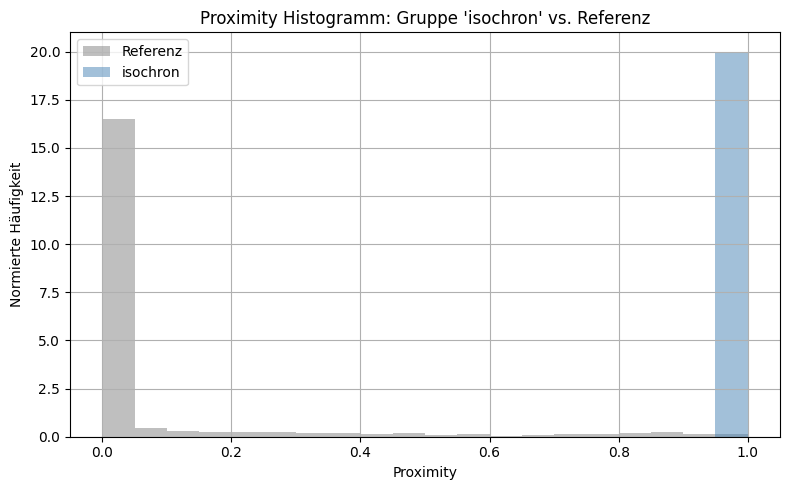

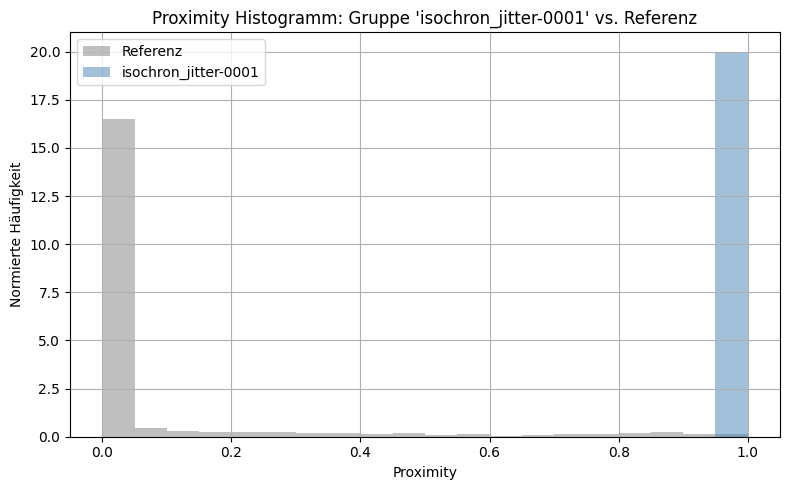

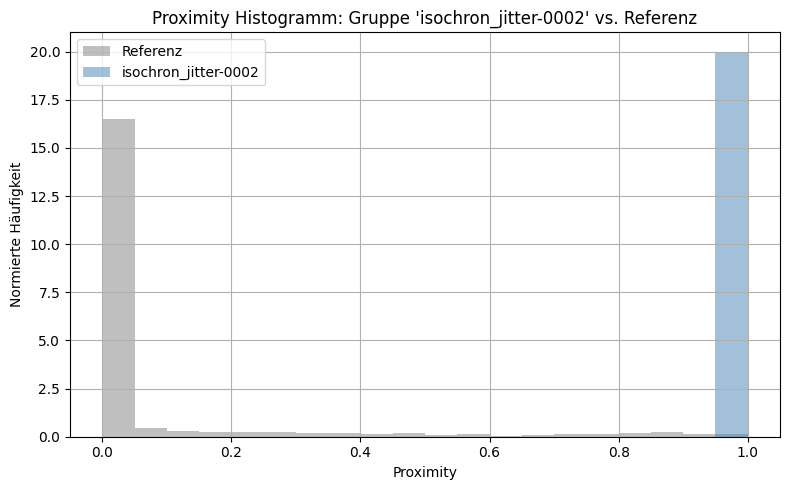

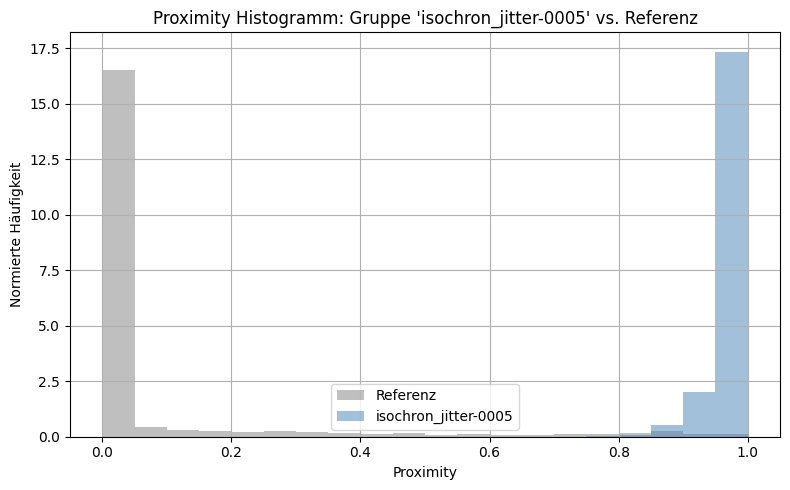

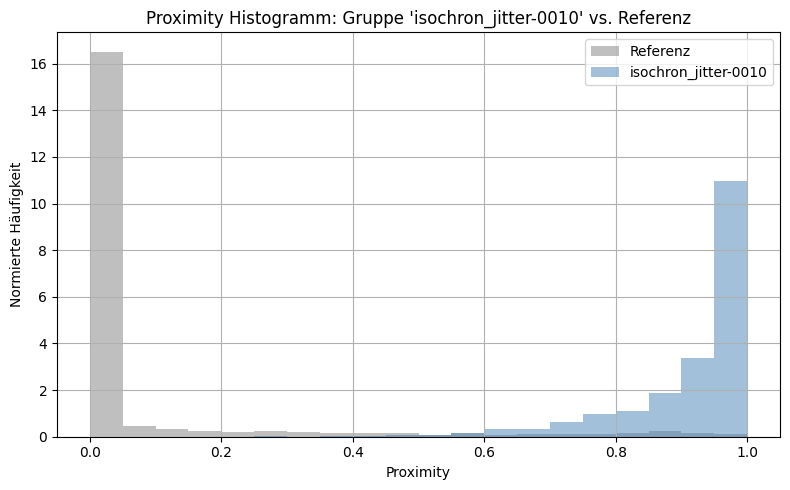

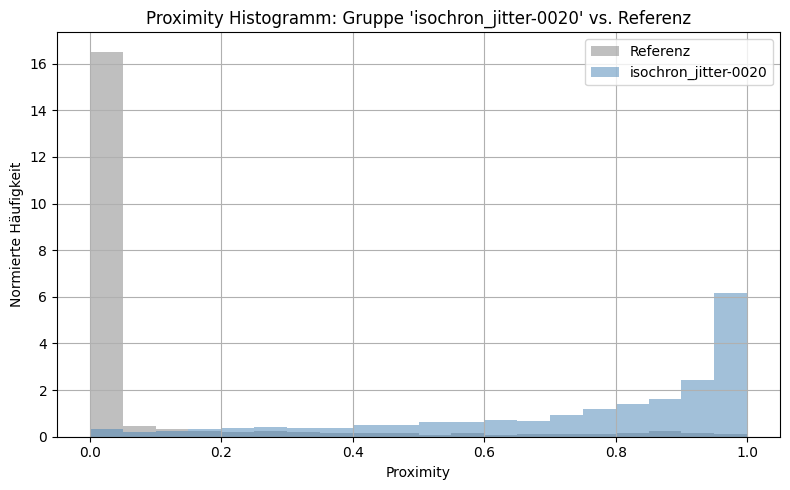

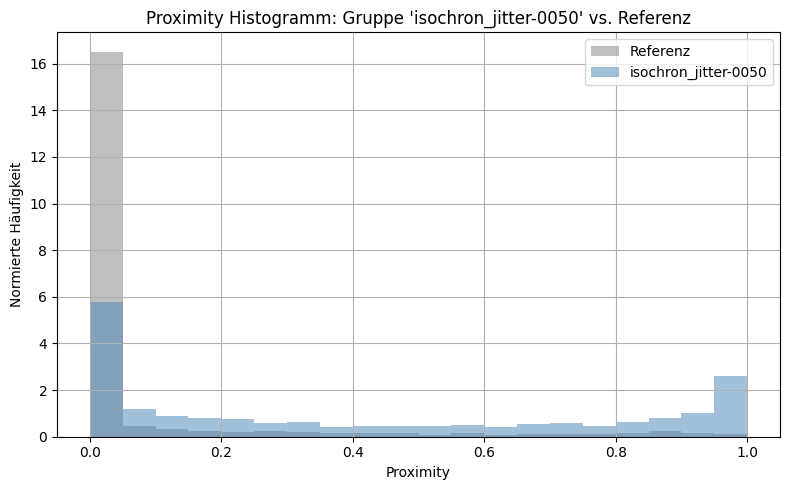

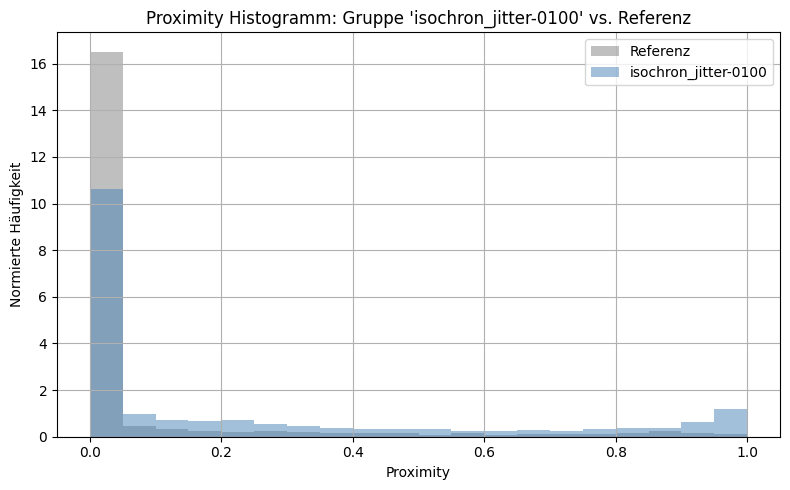

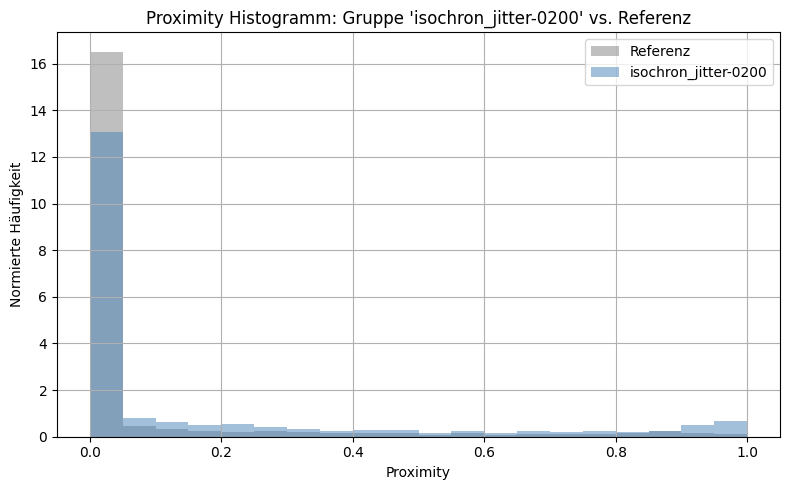

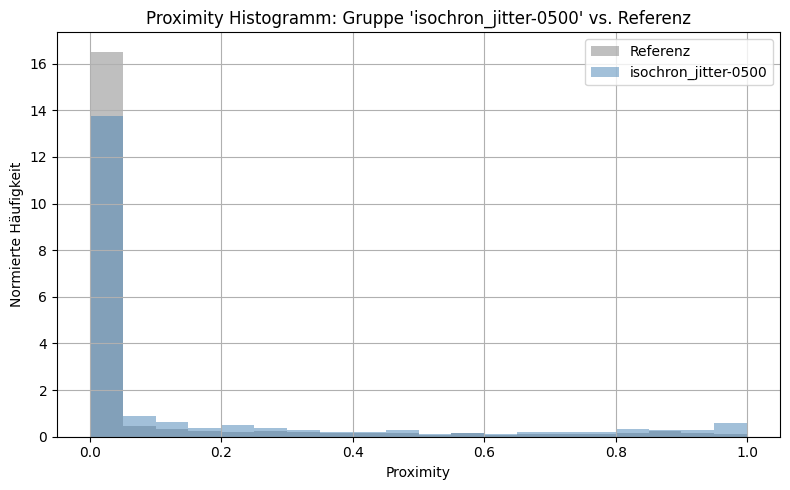

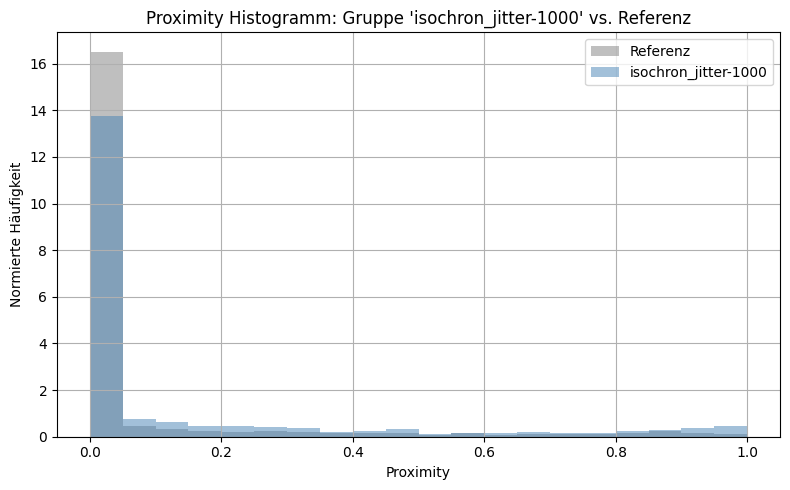

In [6]:
# Analysis of Proximity Values from Synthetic 20-Beats Sequences
# Histogram of Proximity Values for Each Group, compared with the Proximity-Functions Average

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from pathlib import Path

# === Pfad zur 20-Beats Sequenz-Ordner ===
data_dir = Path("../data/theoretical_sequences/baseIOI-0.50/jitter_testing")
all_csv_files = list(data_dir.glob("*.csv"))

# === Container für Ergebnisse ===
all_results = []

# === Funktion zur Gruppierung aus Dateinamen extrahieren ===
def extract_group_name(filename):
    # Entferne Index vor ".csv", z.B. "_04.csv"
    return re.sub(r"_\d+(?=\.csv)", "", filename).replace(".csv", "")

# === Analyse-Funktion wiederverwenden ===
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    all_freq_values = []
    for freq in range(1, max_freq + 1):
        weight = 1 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)
        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness
        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        cos_term_normalized = cos_term / peak_value
        val = weight * cos_term_normalized / (x ** decay)
        all_freq_values.append(val)
    result = np.maximum.reduce(all_freq_values)
    max_at_norm_x = np.max([
        (1 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in range(1, max_freq + 1)
    ])
    return result / max_at_norm_x * output_max

# === Haupt-Loop über alle Dateien ===
for file_path in all_csv_files:
    try:
        df = pd.read_csv(file_path)
        iois = df["IOI"].dropna().values
        if len(iois) < 2:
            continue  # überspringen, wenn zu wenig Daten

        ratios = np.array([[max(x, y) / min(x, y) for x in iois] for y in iois])
        proximity = proximity_max_freq(
            ratios,
            sharpness_base=10.0,
            sharpness_growth=2.0,
            decay=0.1,
            max_freq=4,
            weight_exponent=1.0,
            freq_sharpness_exp=1.0,
            norm_x=1.0,
            output_max=1.0
        )

        # Nur oberes Dreieck ohne Diagonale nehmen
        upper_triangle_values = proximity[np.triu_indices_from(proximity, k=1)]

        # Gruppe extrahieren
        group_name = extract_group_name(file_path.name)

        # Ergebnis speichern
        for val in upper_triangle_values:
            all_results.append({
                "group": group_name,
                "proximity": val
            })

    except Exception as e:
        print(f"Fehler bei Datei {file_path.name}: {e}")

# === In DataFrame umwandeln ===
results_df = pd.DataFrame(all_results)
results_df["group"] = pd.Categorical(results_df["group"], categories=sorted(results_df["group"].unique()), ordered=True)

# Hole alle Gruppen (außer Referenz)
groups = sorted(results_df["group"].unique())

# --- HISTOGRAM ---

# 1. Standard-x-Werte für die Referenz
x_ref = np.linspace(1, 5, 1000)
proximity_ref_values = proximity_max_freq(x_ref,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
)

# Histogramm-Parameter
bins = 20
range_hist = (0, 1)

for group in groups:
    plt.figure(figsize=(8,5))

    # Proximity Werte für die aktuelle Gruppe
    group_values = results_df.loc[results_df["group"] == group, "proximity"]

    # Histogramme plotten
    plt.hist(proximity_ref_values, bins=bins, range=range_hist, alpha=0.5, label="Referenz", color="gray", density=True)
    plt.hist(group_values, bins=bins, range=range_hist, alpha=0.5, label=group, color="steelblue", density=True)

    plt.title(f"Proximity Histogramm: Gruppe '{group}' vs. Referenz")
    plt.xlabel("Proximity")
    plt.ylabel("Normierte Häufigkeit")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
